<div style="border:solid green 2px; padding: 20px">
    
<b>Максим, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Это Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Модель для предсказания вероятности клика на рекламный банер

## План работы
- Построить модель бинарной классификации, которая предсказывает вероятность клика — показатель CTR — на рекламное объявление.
- Поле которое является целевой переменной `click`.
- Оценка модели по трем ключевым метрикам: PR-AUC, Log Loss и оценка Бриера.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Вводная часть имеется

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовка библиотек
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

In [160]:
from pandas.core.common import random_state
# from turtledemo.penrose import start
# from unicodedata import category
!pip install phik -U -q
!pip install scikit-learn -U -q

Exception ignored in: <function ResourceTracker.__del__ at 0x10b4482c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [161]:
#Импорт библиотек
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import phik
from time import time
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.metrics import (
#    accuracy_score,
    brier_score_loss,
#    precision_score,
#    recall_score,
#    f1_score,
    average_precision_score,
#    precision_recall_curve,
    log_loss,
#    classification_report
)
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import (
    calibration_curve,
    CalibrationDisplay,
    CalibratedClassifierCV
)
from sklearn.frozen import FrozenEstimator
import joblib

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Выгружаешь импорты, которые не используешь в проекте

<div class="alert alert-info"> <b>Комментарии студента:</b> Привет Александр, убрал неиспользуемые импорты.</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 
Супер, старайся, пожалуйста, придерживаться этой стратегии в дальнейших проектах =)
</div>

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

In [162]:
RANDOM_STATE = 42
N_FOLDS = 5

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [163]:
# Загрузка данных
df = pd.read_csv("datasets/ds_s16_ad_click_dataset.csv", sep=',', decimal='.')
df_len = len(df)

In [164]:
# Информация о датасете
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

In [165]:
# Выводим первые строки первой половины столбцов датафрейма на экран
df.iloc[:, :len(df.columns)//2].head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702


In [166]:
# Выводим первые строки второй половины столбцов датафрейма на экран
df.iloc[:, len(df.columns)//2:].head()

,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


In [167]:
#Выведем статистику по датасету
df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,...,C20,C21,ml_feature_1,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.215402e+18,0.172060,1.410256e+07,1004.970060,0.291380,1.018120,0.337160,18826.648680,318.86640,59.692480,...,53173.383240,83.685180,-0.002445,-0.036381,0.498040,0.034729,0.022948,0.025465,0.035361,0.020226
std,5.328516e+18,0.377436,2.967892e+02,1.110202,0.514201,0.538477,0.860057,4983.064178,20.56153,46.720842,...,49960.181871,70.539513,1.000280,5.792335,0.500001,1.002116,0.656690,0.578026,0.505034,0.303309
min,3.191077e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.00000,20.000000,...,-1.000000,13.000000,-4.631262,-9.999742,0.000000,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,4.580649e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.00000,50.000000,...,-1.000000,23.000000,-0.677784,-5.059555,0.000000,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,9.243015e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.00000,50.000000,...,100049.000000,61.000000,-0.003776,-0.056155,0.000000,0.028112,0.037786,0.027348,0.035985,0.018930
75%,1.380920e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21916.000000,320.00000,50.000000,...,100094.000000,108.000000,0.673534,4.985939,1.000000,0.707594,0.637131,0.521117,0.374152,0.224080
max,1.844652e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.00000,1024.000000,...,100248.000000,255.000000,3.793828,9.999975,1.000000,4.230623,1.000000,1.119858,2.120786,1.202300



Названия столбцов уже приведены к единому виду snake_case.

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Датасет загружен, базовый осмотр сделан

## 2. Исследовательский анализ данных (EDA)


#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.


Датасет ds_s16_ad_click_dataset содержит 33 столбца и 50000 строк, в которых представлена информация о рекламных объявлениях.

В датасете представлено 19 категориальных признаков:
- id, banner_pos, C1, C15, C16, C18,
- site_id, site_domain, site_category, 
- app_id, app_domain, app_category, 
- device_id, device_ip, device_model, device_type, device_conn_type, 
- ml_feature_2, ml_feature_7.

Один признак datetime:
- hour

остальные 13 признаков числовые


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

У тебя "hour", "device_type", "device_conn_type", "banner_pos", "C1", "C15", "C16", "C18" трактуются как числовые, хотя часть из них по смыслу категориальные или дискретные кодовые признаки

<div class="alert alert-info"> <b>Комментарии студента:</b> хм, не обратил внимание .</div>

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.


click - был ли совершён клик по баннеру. 1 — клик был, 0 — клика не было.
Столбец click содержит целые числа и хранится в типе данных int64, размерность этих данных можно оптимизировать.
Пропусков в данном столбце в датасете нет.

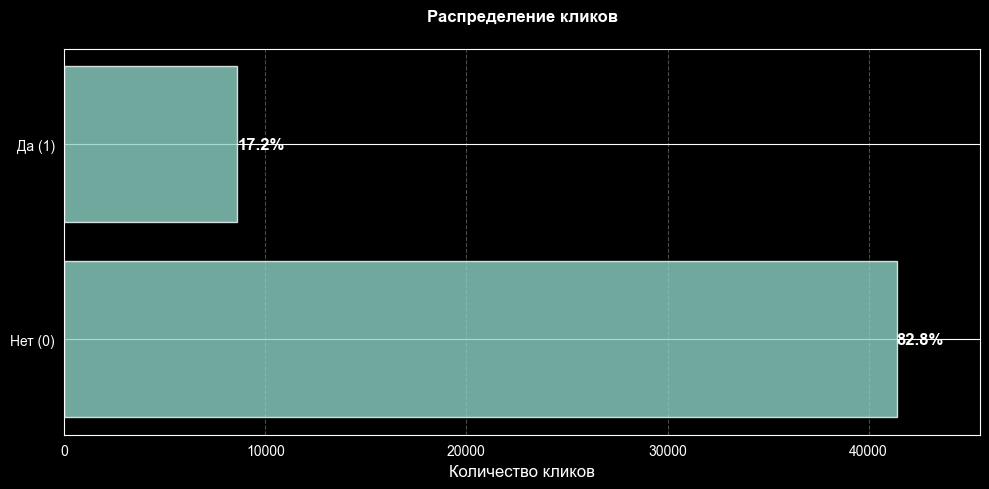

In [168]:
# Распределение оттока клиентов
plt.figure(figsize=(10, 5))

counts = df['click'].value_counts()
bars = plt.barh(['Нет (0)', 'Да (1)'], counts.values, alpha=0.8)

for bar, count in zip(bars, counts.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2.,
        f'{count/len(df)*100:.1f}%',
        ha='left', va='center', fontsize=12, fontweight='bold'
    )

plt.title('Распределение кликов', fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Количество кликов', fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.xlim(0, max(counts.values) * 1.1)
plt.tight_layout()
plt.show()

В распределении явный дисбаланс классов, 17.2% клик был и 82.8% клика не было, исходя из явного дисбаланска классов для поиска оптимальной модели лучше опираться на метрику PR-AUC.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Основная метрика "PR-AUC" выбрана правильно

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.


Для обучения модели точно не понадобится признак id записи показа баннера так как он уникален и является идентификатором события(строки), этот признак можно сразу удалить.
device_id и device_ip малоинформативные признаки для базовой модели, id просто идентификатор, а ip сам по себе ничего не дает если не сделать из него новую фичу.

In [169]:
#Удаляем столбец
#df = df.drop(columns=['id', 'device_id', 'device_ip'])

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Ты удаляешь "device_id" и "device_ip" еще до разбиения на train/test. Это преждевременное feature selection на полном датасете. Даже если признаки потом действительно не нужны, решение об их удалении нельзя фиксировать на всем датасете до split
    
    
<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__
    
    
Аналогично потом в EDA удаляются    
    
    df = df.drop(columns=['ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'site_domain', 'app_domain'])
    
    
Это уже явная утечка, потому что удаление основано на анализе корреляций по всему датасету    

<div class="alert alert-info"> <b>Комментарии студента:</b> закоментировал.</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 
Учтено

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

In [170]:
# Сколько строк имеют хотя бы один пропуск
rows_with_nan = df.isna().any(axis=1).sum()
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_nan} из {len(df)} "
      f"({rows_with_nan/len(df)*100:.2f}%)")


Строк с хотя бы одним пропуском: 0 из 50000 (0.00%)


Так как данные без пропусков, заплонять их не нужно.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Проверка пропусков проведена корректно

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.


In [171]:
cat_features = [
#    'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_model', 'ml_feature_7'
    'id', 'banner_pos', 'C1', 'C15', 'C16', 'C18',
    'site_id', 'site_domain', 'site_category', 
    'app_id', 'app_domain', 'app_category', 
    'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 
    'ml_feature_2', 'ml_feature_7',
]

In [172]:
#Количество уникальных значений в столбцах
df[cat_features].nunique().sort_values()

ml_feature_7            3
C18                     4
device_conn_type        4
device_type             4
ml_feature_2            5
banner_pos              7
C1                      7
C15                     8
C16                     9
site_category          18
app_category           22
app_domain             67
app_id                976
site_domain          1013
site_id              1160
device_model         2521
device_id            8580
device_ip           41455
id                  50000
dtype: int64

Признаки ml_feature_7, C18, device_conn_type, device_type, ml_feature_2, banner_pos, C1, C15, C16,
можно закодировать при помощи One-Hot Encoding, так как у этих признаков небольшое число уникальных значений.
Остальные признаки лучше кодировать Target Encoding, так как при кодировании One Hot приведет увеличению количества параметров в тысячи раз.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Посчитана кардинальность категориальных признаков

<div class="alert alert-info"> <b>Комментарии студента:</b> Дополнил переменную cat_features в соответствии с замечанием выше.</div>

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.


In [173]:
def plot_distribution(tmp_df, bin_col, second_col, title, x_label, y_label='Плотность', figsize=(16, 6), fontsize=12, bins=40):
    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [2, 1]})
    click0 = tmp_df[tmp_df[bin_col]==0][second_col]
    click1 = tmp_df[tmp_df[bin_col]==1][second_col]

    ax1 = axes[0]
    ax1.hist(click0, bins=bins, alpha=0.5, label='Нет (0)', color='lightcoral', edgecolor='black', density=True)
    ax1.hist(click1, bins=bins, alpha=0.5, label='Да (1)', color='lightblue', edgecolor='black', density=True)

    ax1.axvline(click0.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Среднее (0): {click0.mean():.2f}')
    ax1.axvline(click1.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Среднее (1): {click1.mean():.2f}')
    ax1.axvline(click0.median(), color='red', linestyle=':', linewidth=2, label=f'Медиана (0): {click0.median():.2f}')
    ax1.axvline(click1.median(), color='blue', linestyle=':', linewidth=2, label=f'Медиана (1): {click1.median():.2f}')

    ax1.set_title(title, fontsize=fontsize, fontweight='bold')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel(y_label)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    data_to_plot = [click0, click1]
    box = ax2.boxplot(data_to_plot, vert=True, patch_artist=True, tick_labels=['Нет (0)', 'Да (1)'])

    colors = ['lightcoral', 'lightblue']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax2.set_xlabel('Совершен клик')
    ax2.set_title('Ящик с усами', fontsize=fontsize, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

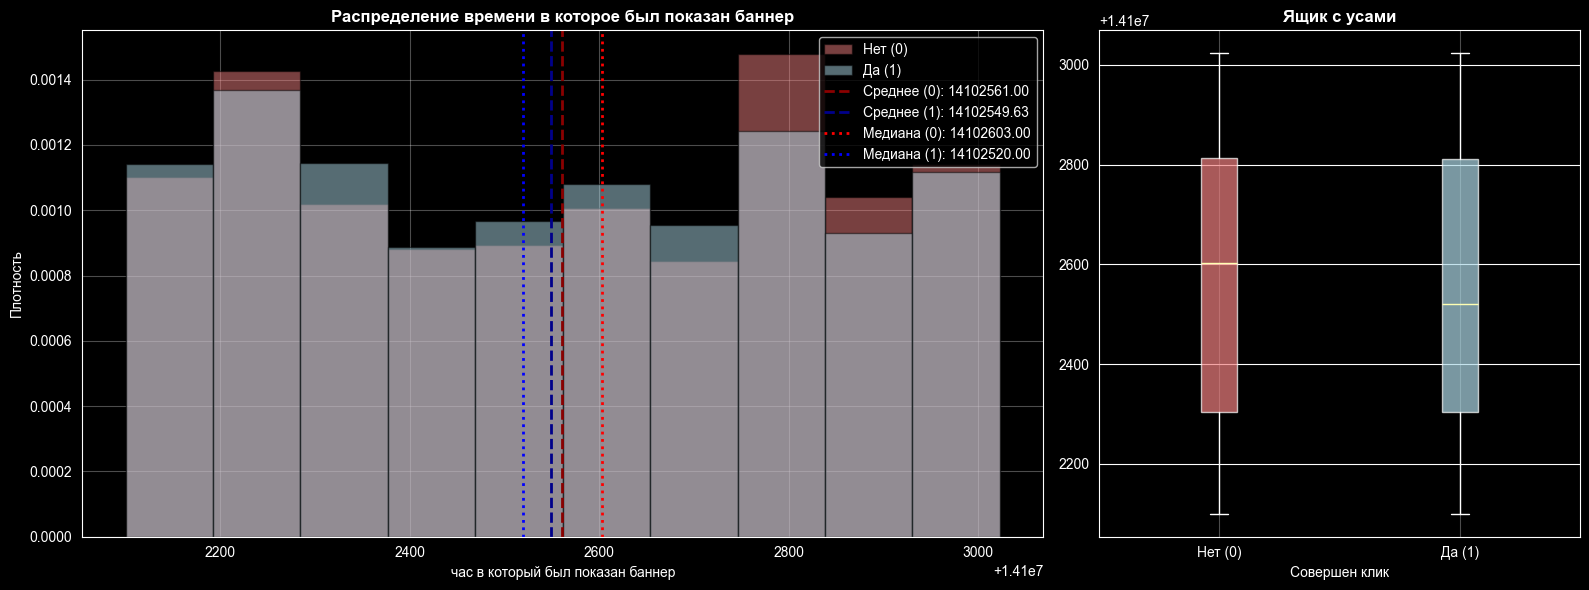

In [174]:
plot_distribution(df, 'click', 'hour',
            'Распределение времени в которое был показан баннер', 'час в который был показан баннер', bins=10)

Распределение по дням нормальное. Судя по распределению все данные приведены за октябрь 2014 года с 21 по 30 числа, все в 00 часов, похоже на ошибку/неточноть/агрегацию в данных. Выбросов в данных нет.

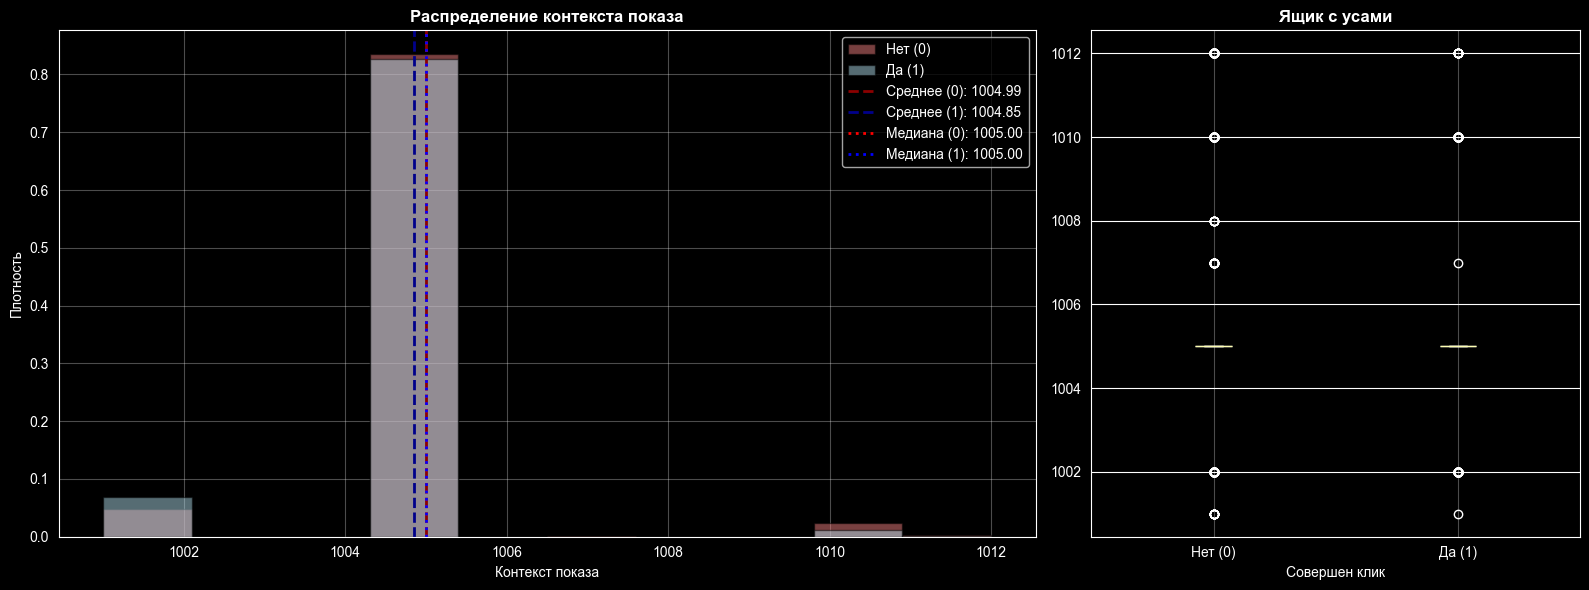

In [175]:
plot_distribution(df, bin_col='click', second_col='C1',
            title='Распределение контекста показа', x_label='Контекст показа', bins=10)

Бользая часть значений признака C1 сконцентрирована на отметке 1005, остальные значения их фоне выглядят выбросами.

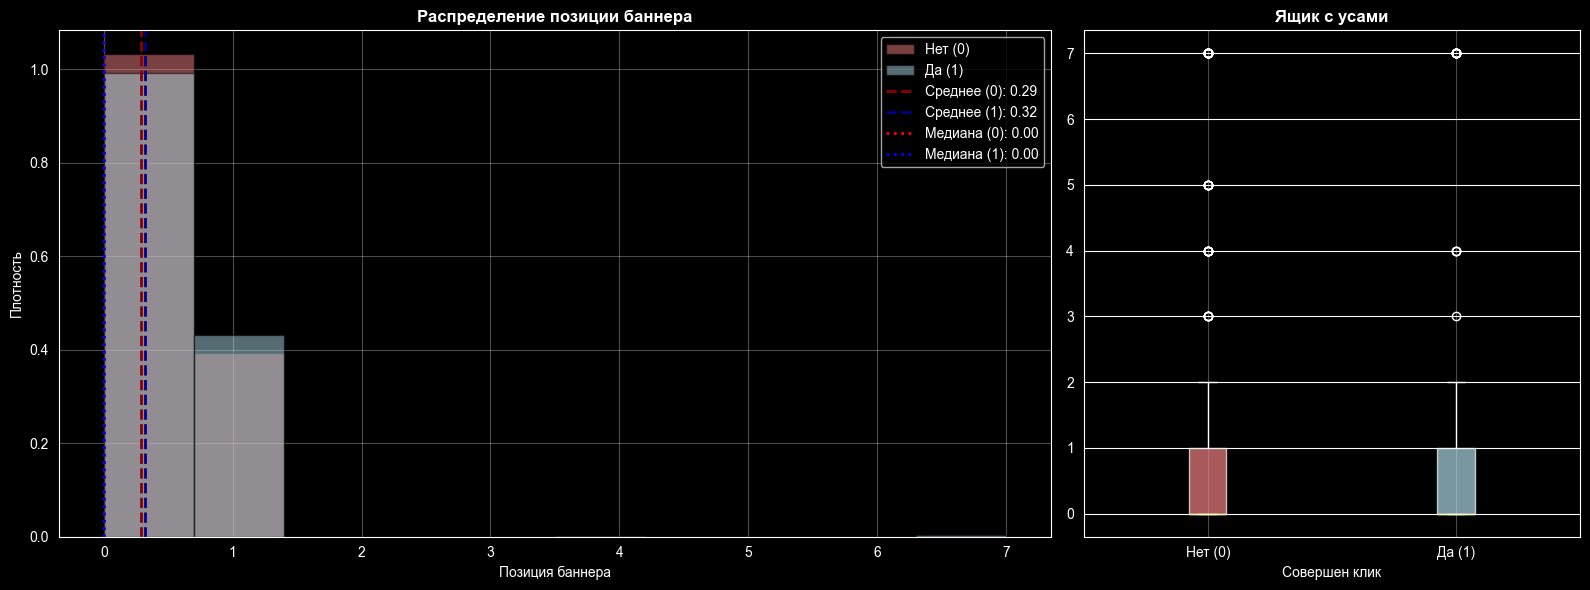

In [176]:
plot_distribution(df, 'click', 'banner_pos',
            'Распределение позиции баннера', 'Позиция баннера', bins=10)

Большая часть измерений сконцентрирована в позициях 0 и 1.

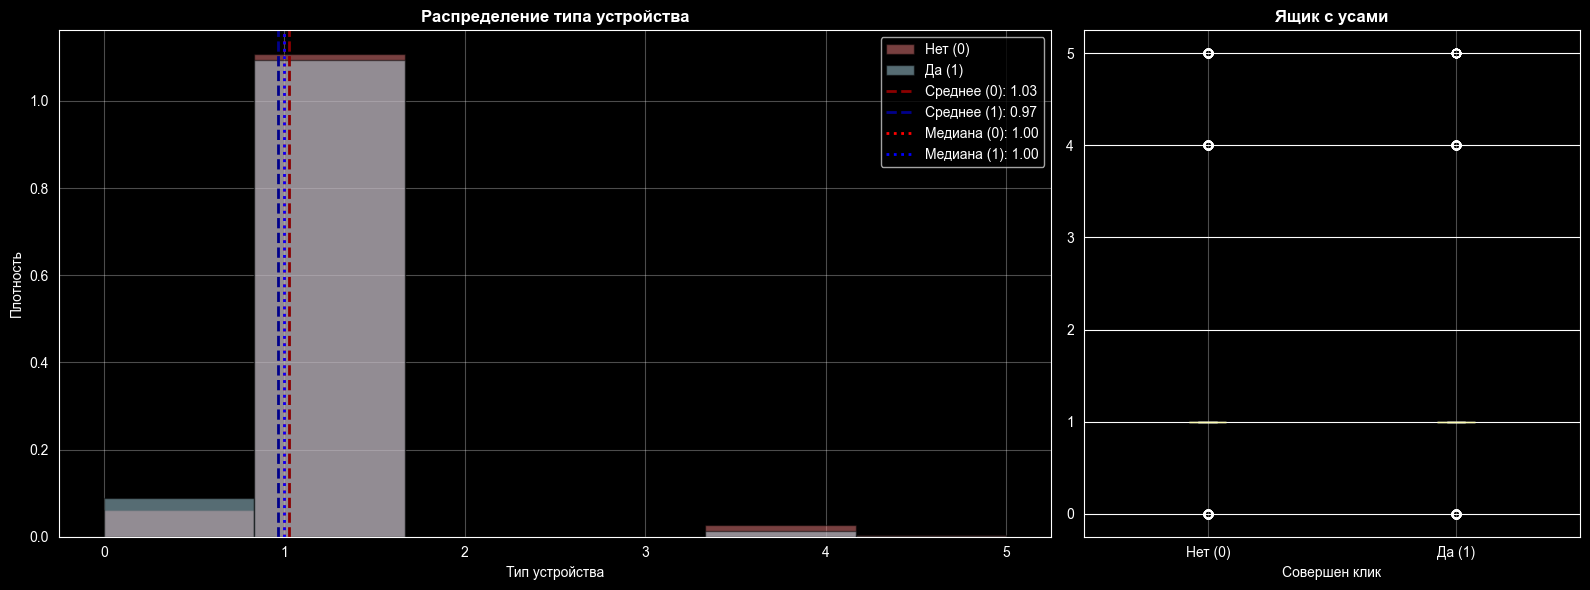

In [177]:
plot_distribution(df, 'click', 'device_type',
            'Распределение типа устройства', 'Тип устройства', bins=6)

Большая часть устройств имеет тип 1.

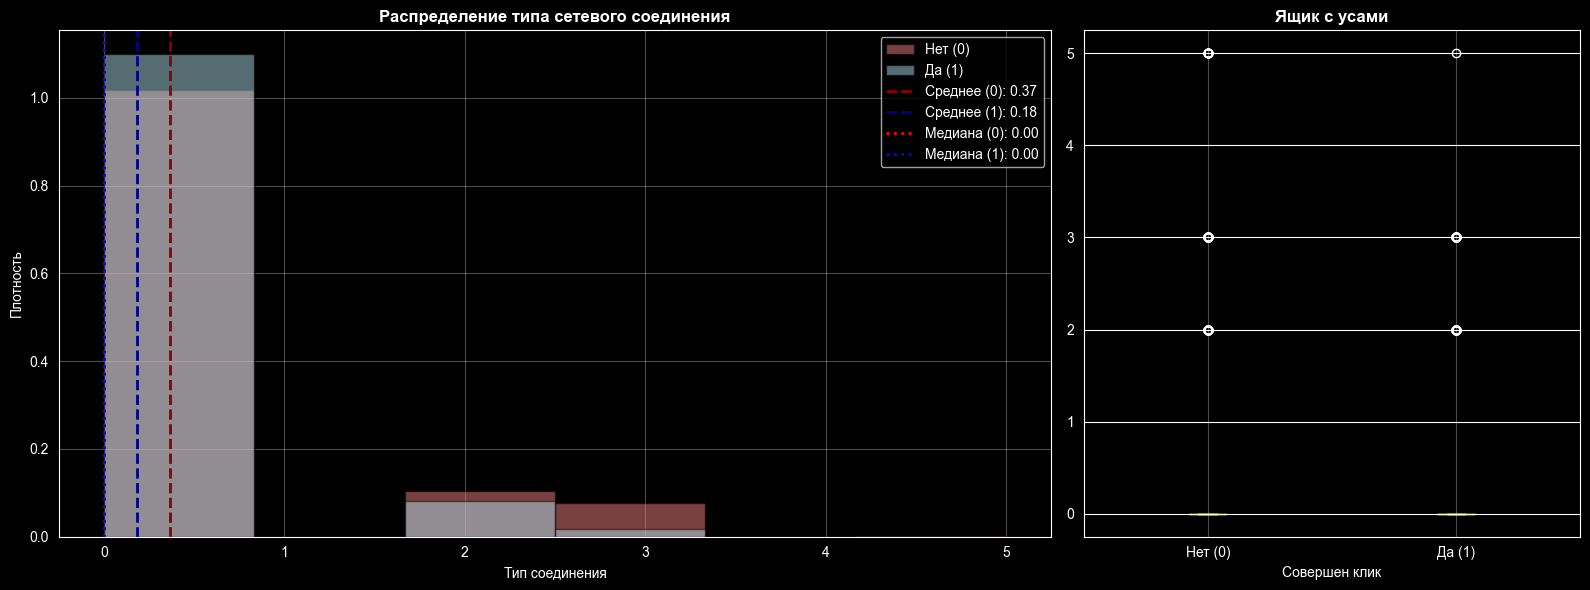

In [178]:
plot_distribution(df, 'click', 'device_conn_type',
            'Распределение типа сетевого соединения', 'Тип соединения', bins=6)

Распределение с хвостом в право. Большая часть типов сетевого соединения - 0.

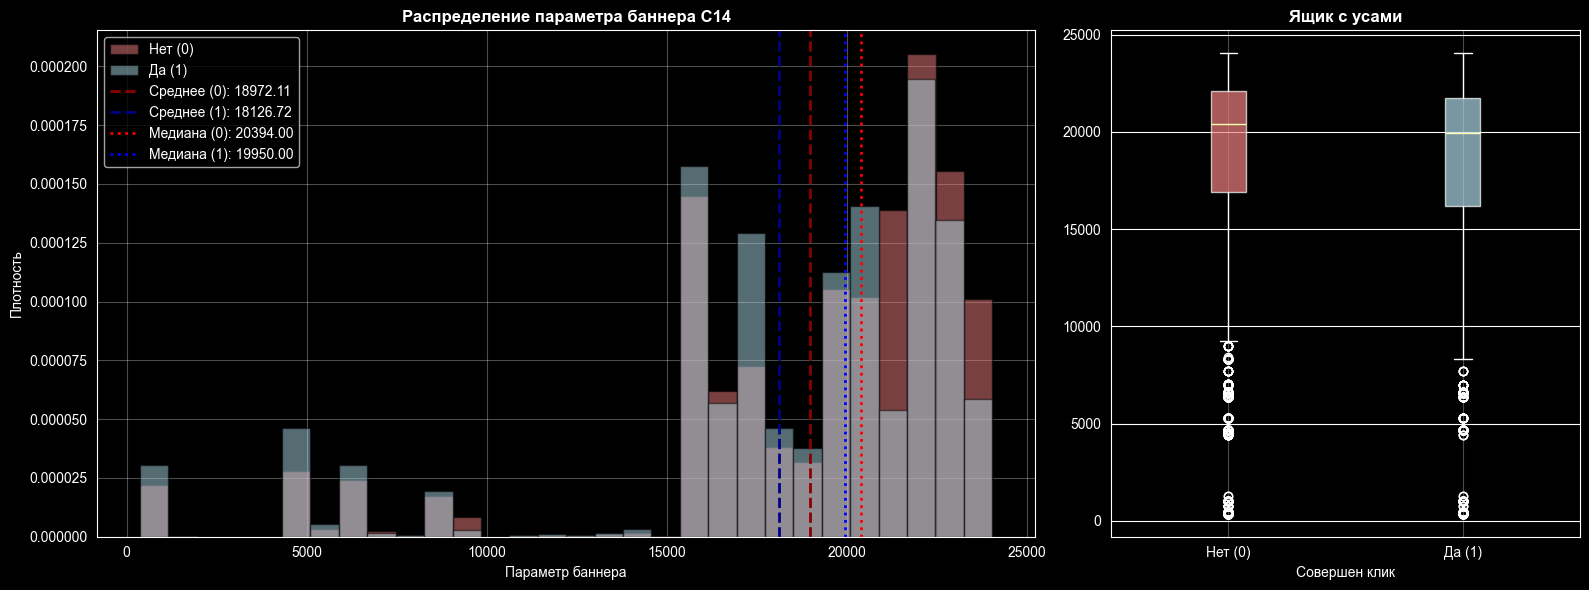

In [179]:
plot_distribution(df, 'click', 'C14',
            'Распределение параметра баннера C14', 'Параметр баннера', bins=30)

Распределение с левым хвостом. Большая часть сзачений в диапазоне 16000 - 21000, с выбросами ниже 4000.

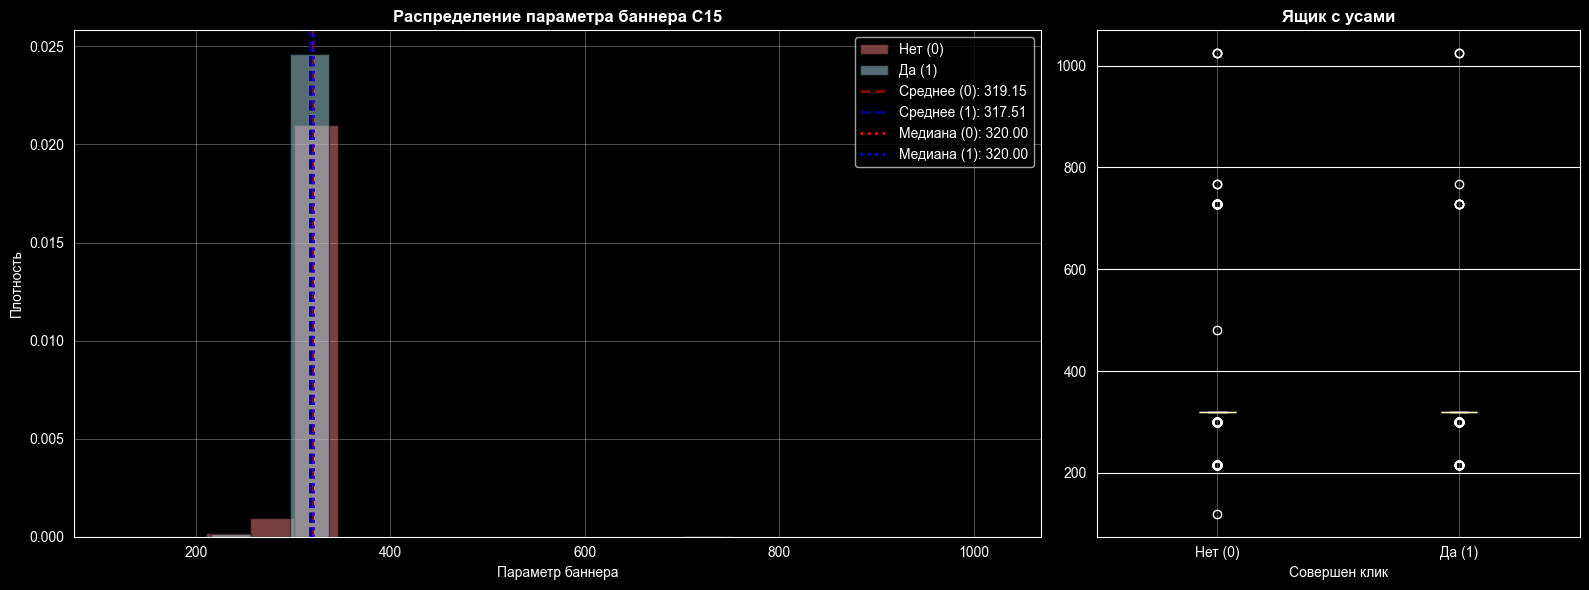

In [180]:
plot_distribution(df, 'click', 'C15',
            'Распределение параметра баннера C15', 'Параметр баннера', bins=20)

Правтически все значения параметра C15 сконцентрированы в области 300, с выбросами ниже 200 и от 400 до 1000 и выше.

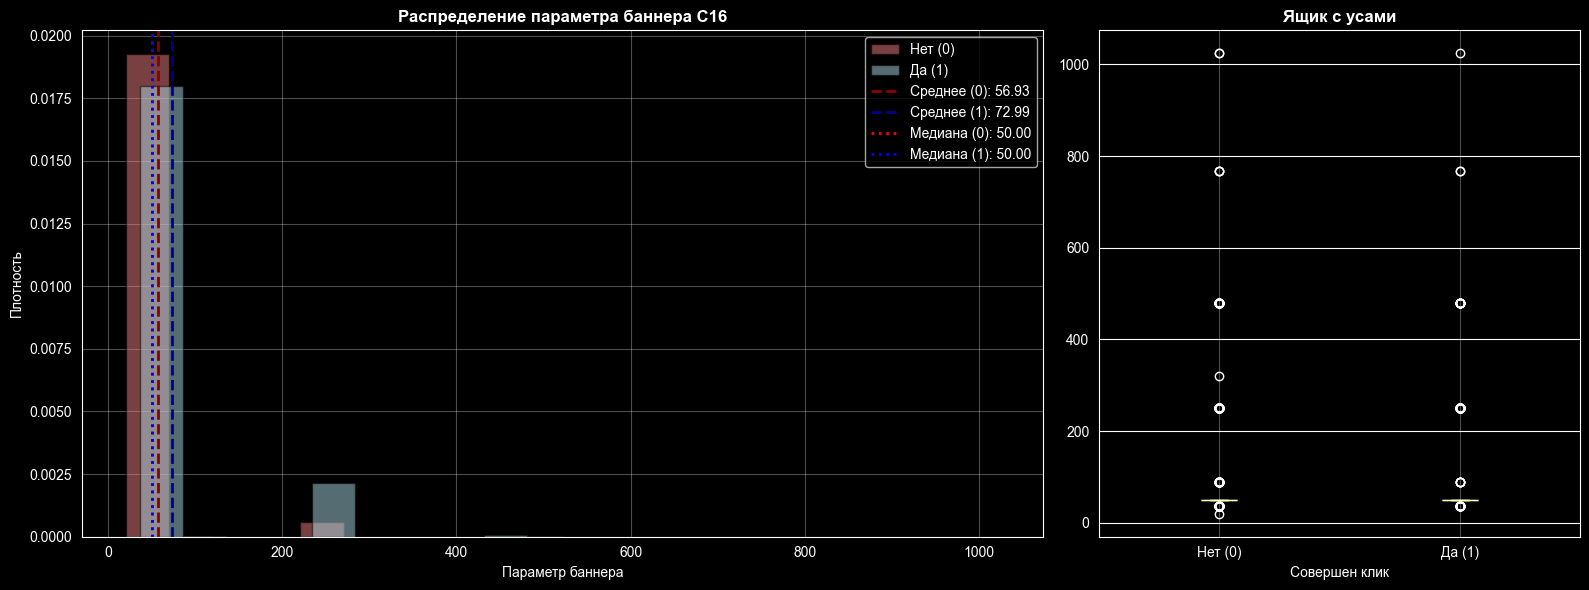

In [181]:
plot_distribution(df, 'click', 'C16',
            'Распределение параметра баннера C16', 'Параметр баннера', bins=20)

Правтически все значения параметра C16 сконцентрированы в области 50, с выбросами от 200 до 1000 и выше.

Exception ignored in: <function ResourceTracker.__del__ at 0x106e182c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106e682c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3

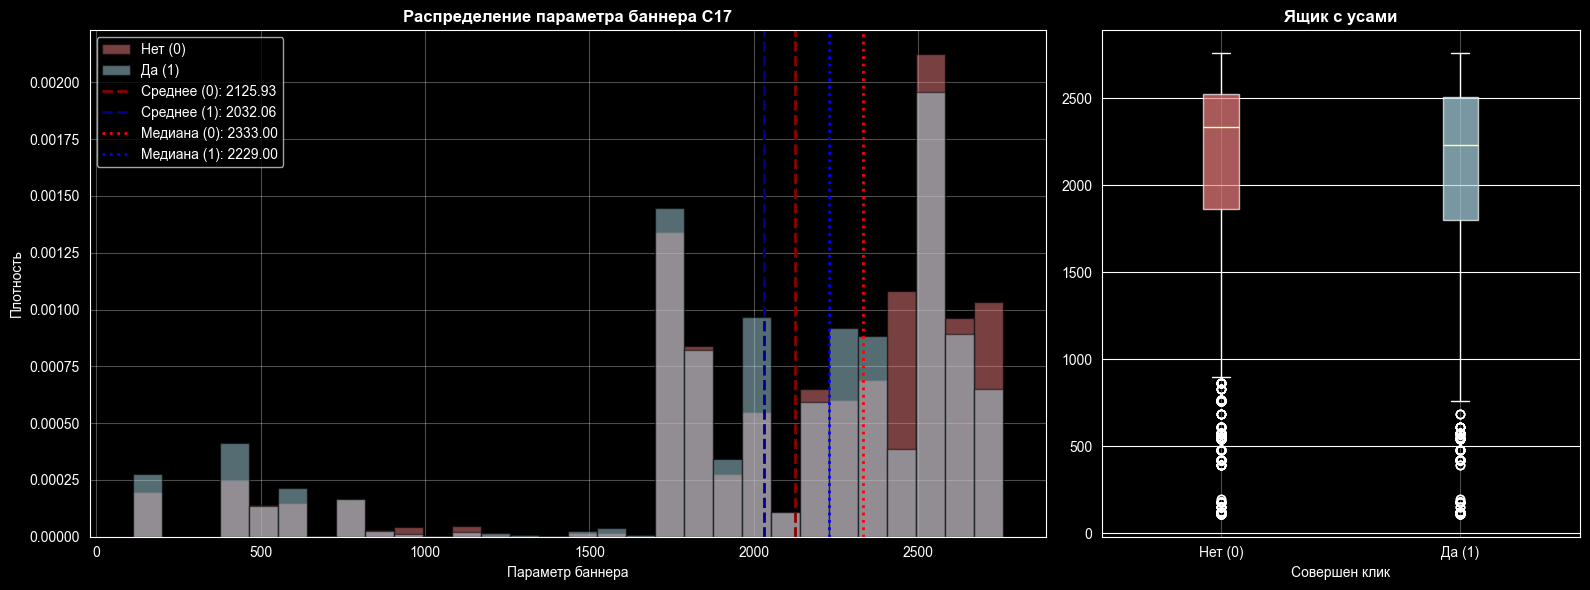

Exception ignored in: <function ResourceTracker.__del__ at 0x1071a42c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [182]:
plot_distribution(df, 'click', 'C17',
            'Распределение параметра баннера C17', 'Параметр баннера', bins=30)

Распределение с левым хвостом,  большая часть значений сс диапазоне от 1700 до 2700.

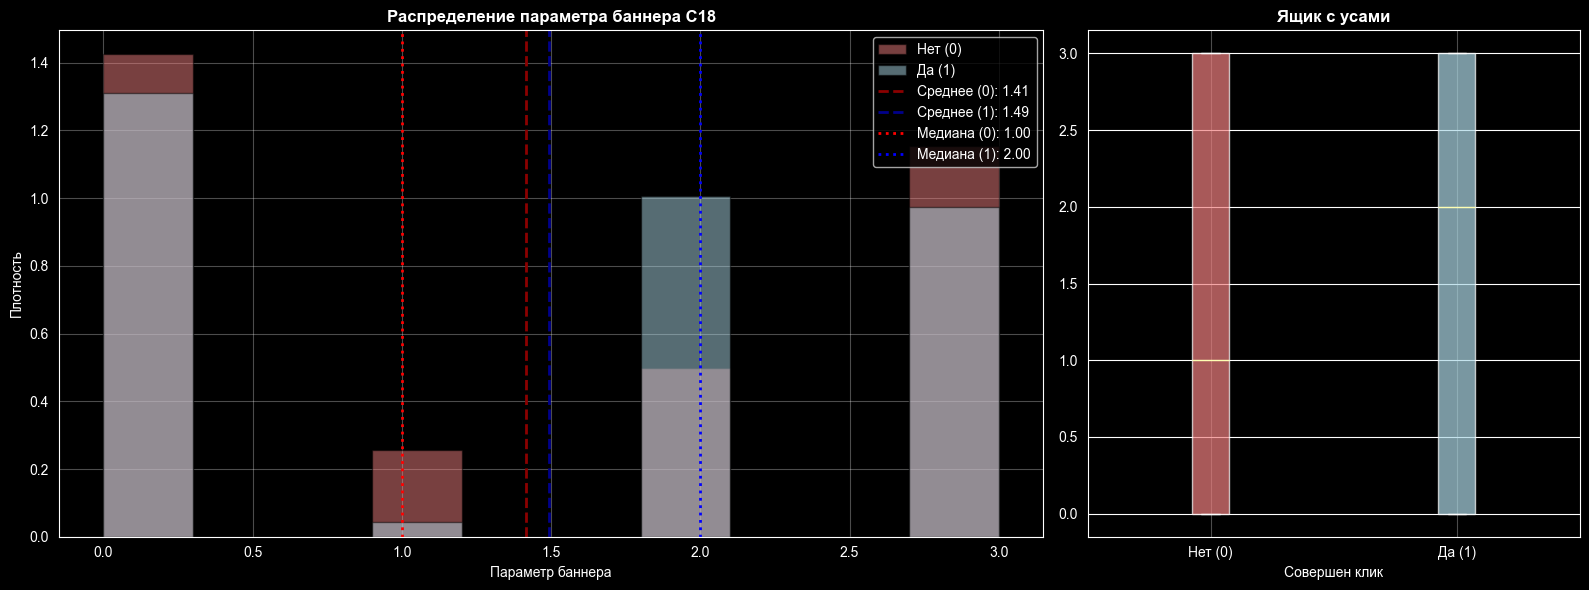

In [183]:
plot_distribution(df, 'click', 'C18',
            'Распределение параметра баннера C18', 'Параметр баннера', bins=10)

Распределение близко к бимодальному с пиками по краям. Большинство измерений находятся на отметках 0 и 3.

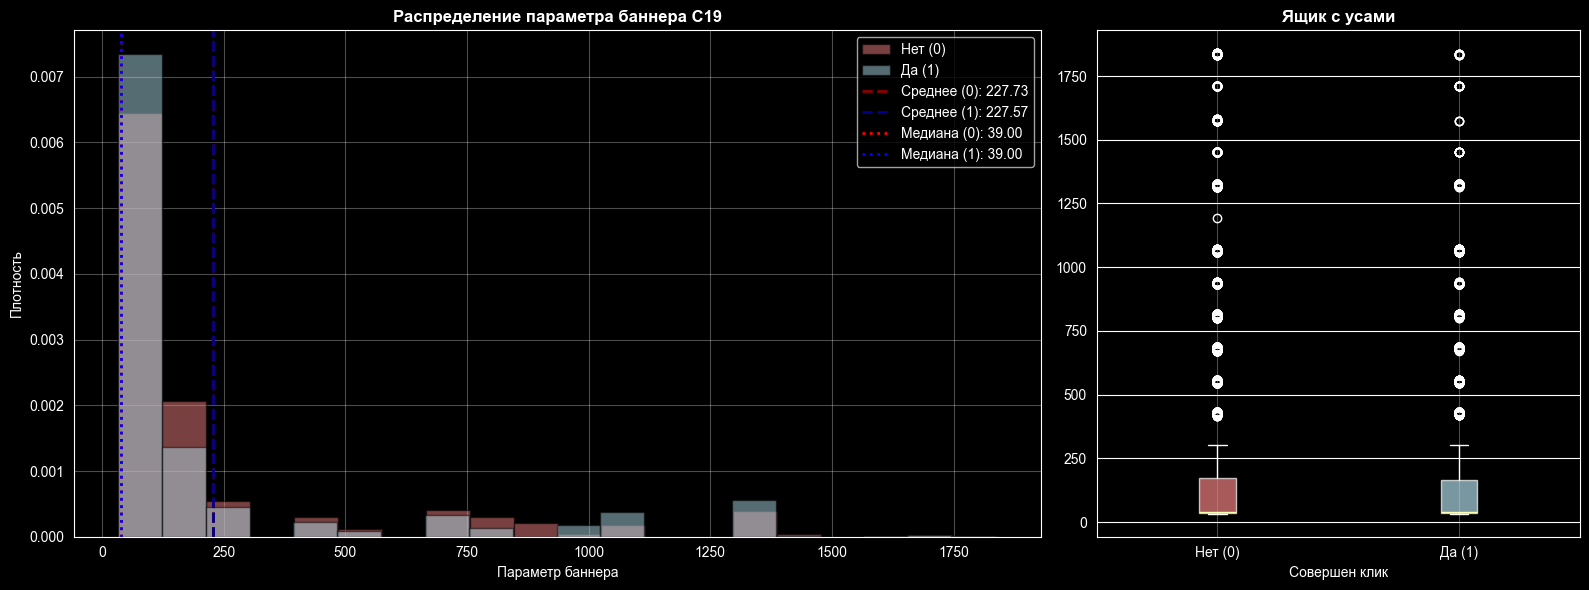

In [184]:
plot_distribution(df, 'click', 'C19',
            'Распределение параметра баннера C19', 'Параметр баннера', bins=20)

Распределение с длинным хвостом в право, большая частьизмерений от 0 до 100.

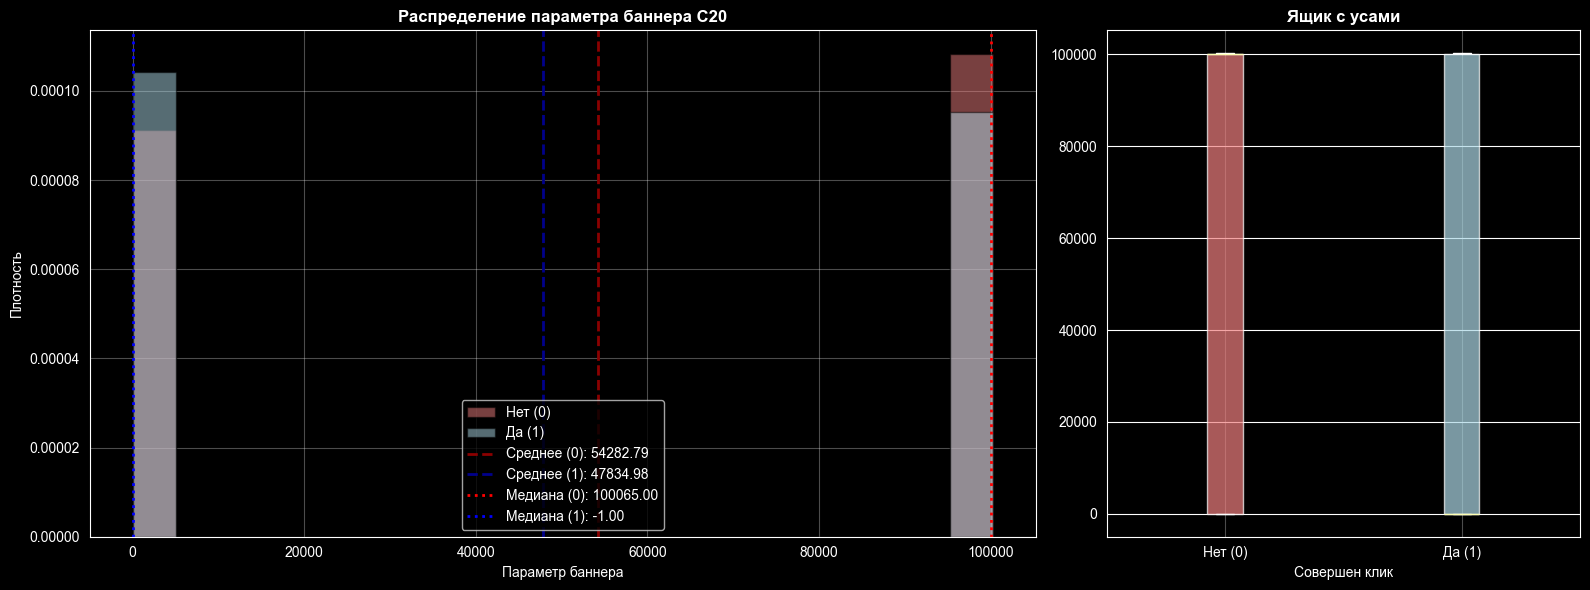

In [185]:
plot_distribution(df, 'click', 'C20',
            'Распределение параметра баннера C20', 'Параметр баннера', bins=20)

На распределении два пикав области 0 и 100000. Судя по распределению, признак похоже бинарный.

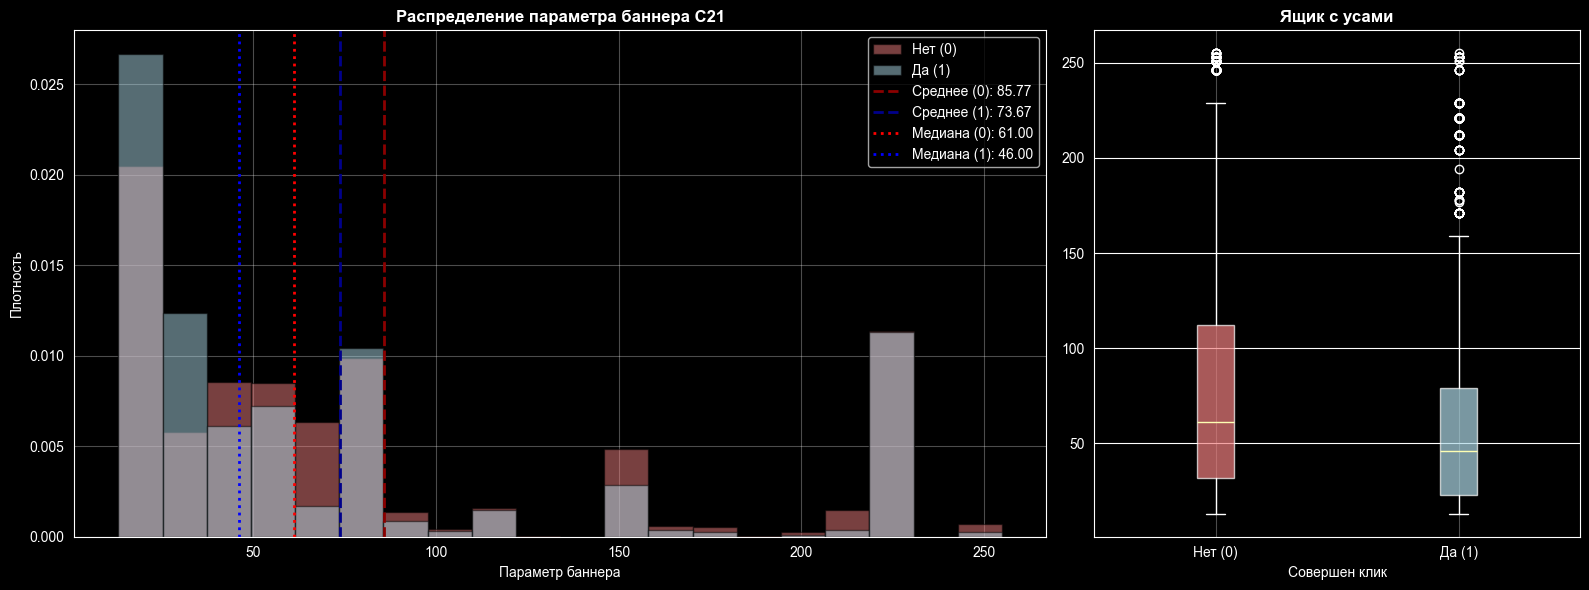

In [186]:
plot_distribution(df, 'click', 'C21',
            'Распределение параметра баннера C21', 'Параметр баннера', bins=20)

Распределение с хвостом в право, большая часть значений в области от 0 до 80.

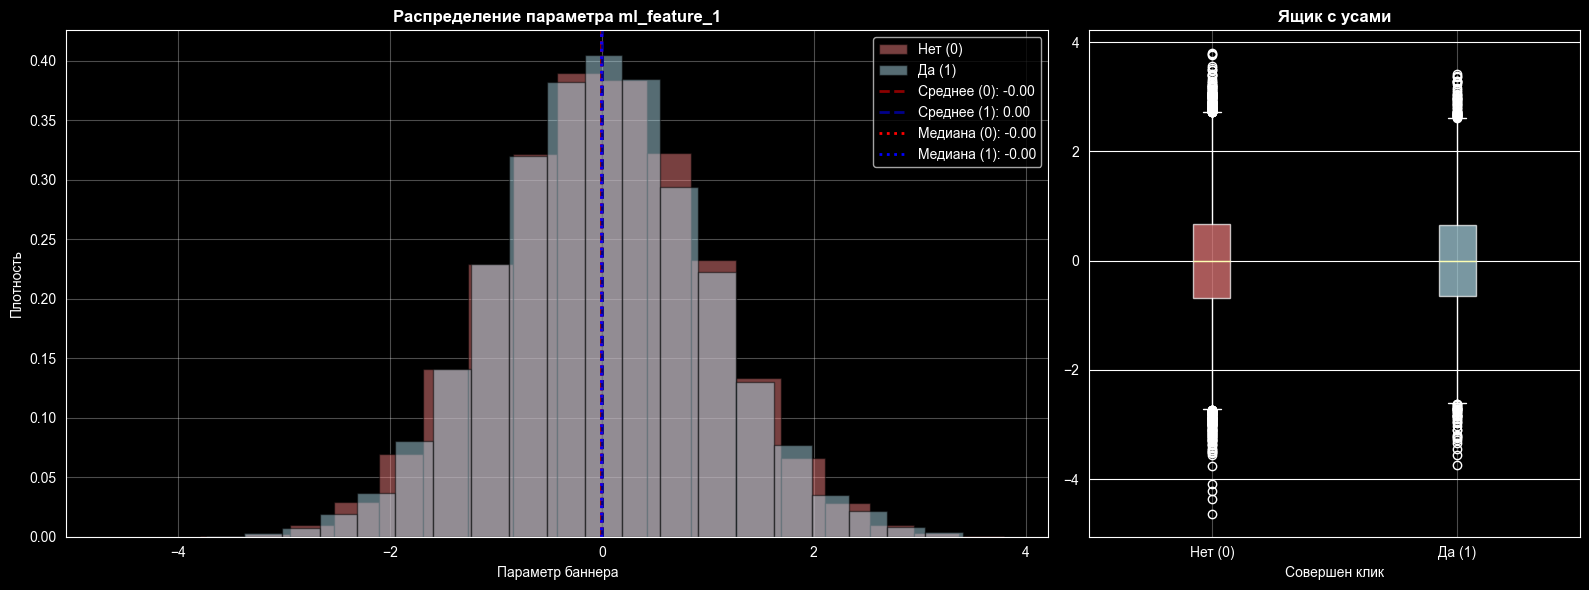

In [187]:
plot_distribution(df, 'click', 'ml_feature_1',
            'Распределение параметра ml_feature_1', 'Параметр баннера', bins=20)

Симметричное распределение с пиком в области 0.

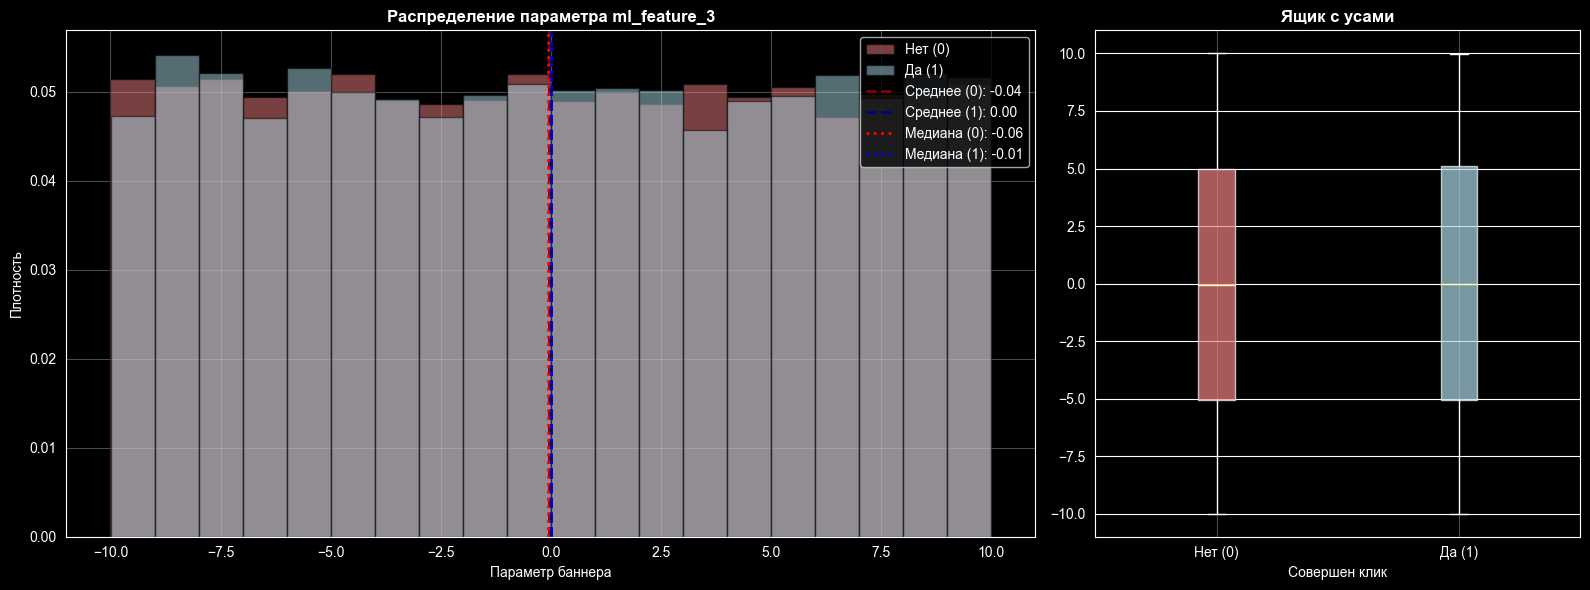

In [188]:
plot_distribution(df, 'click', 'ml_feature_3',
            'Распределение параметра ml_feature_3', 'Параметр баннера', bins=20)

Равномерное распределение от -10 до 10.

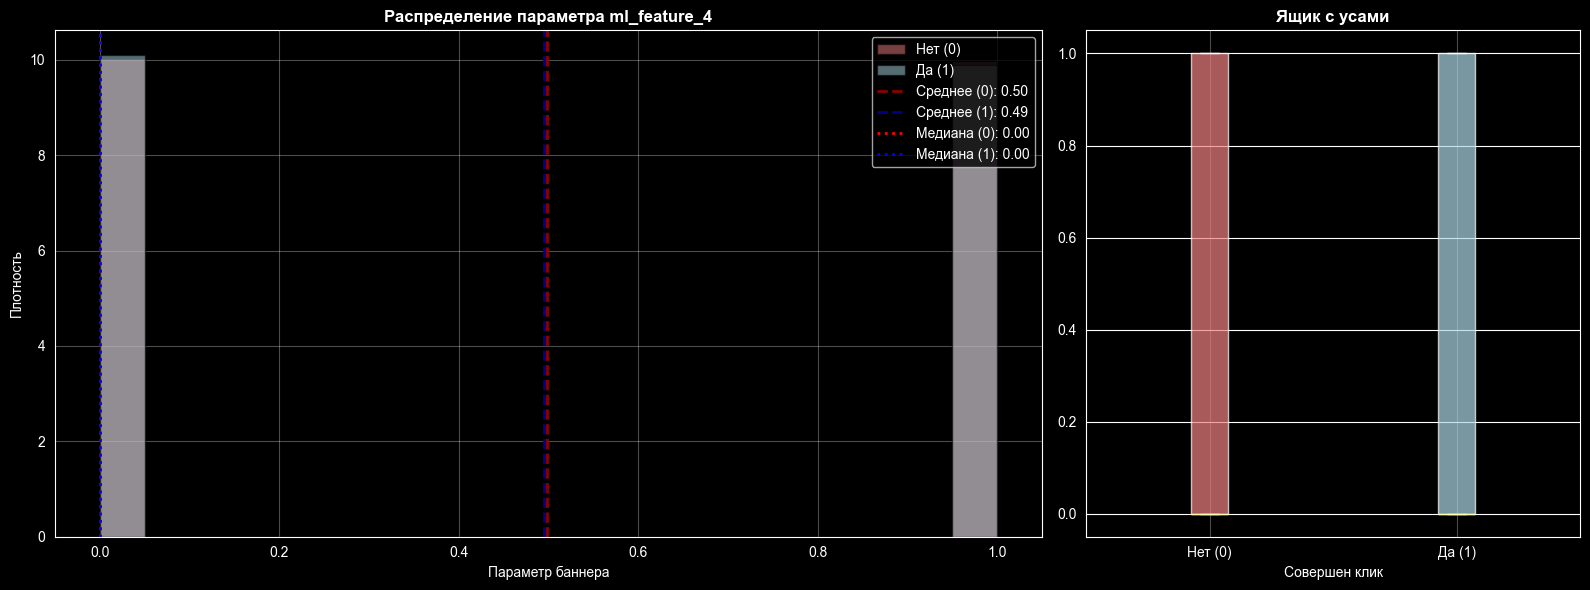

In [189]:
plot_distribution(df, 'click', 'ml_feature_4',
            'Распределение параметра ml_feature_4', 'Параметр баннера', bins=20)

Бинарный признак ml_feature_4, равномерно распределен между классами click0 и click1.

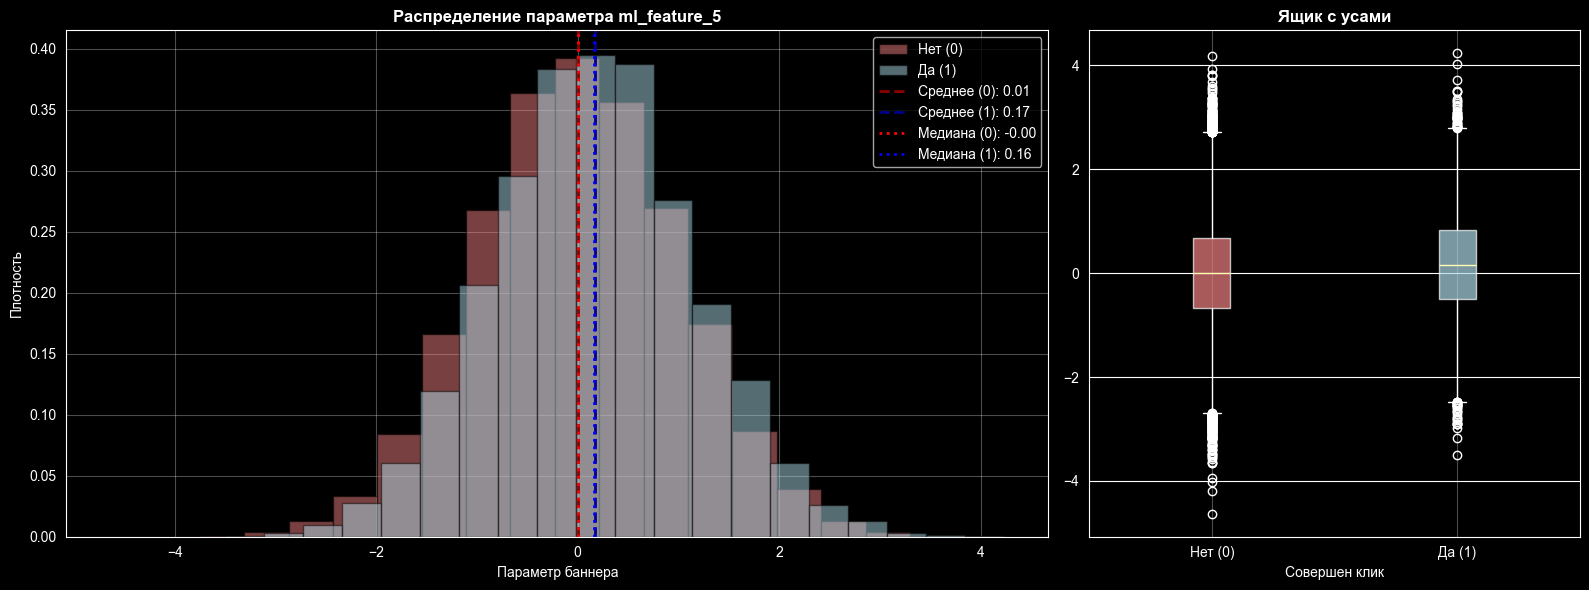

In [190]:
plot_distribution(df, 'click', 'ml_feature_5',
            'Распределение параметра ml_feature_5', 'Параметр баннера', bins=20)

Симметричное распределение для двух классов, но класс Да смещен относительно 0 вправо.


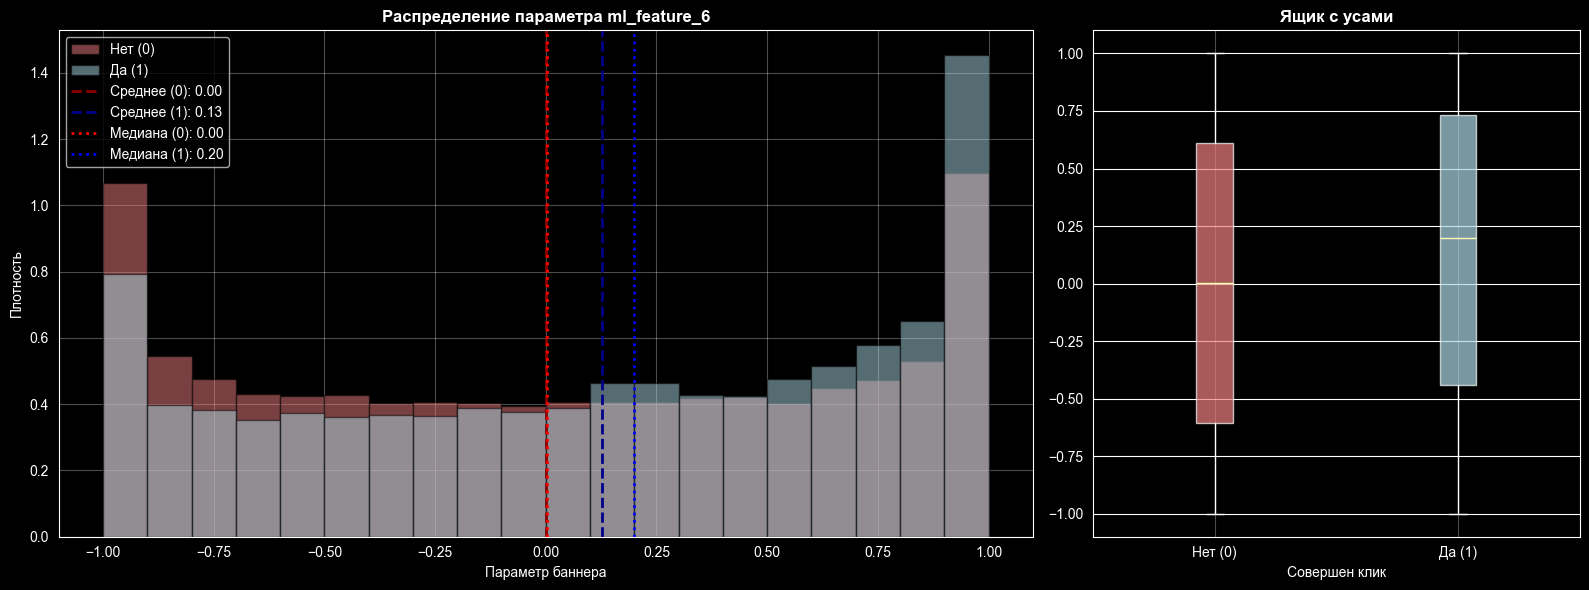

In [191]:
plot_distribution(df, 'click', 'ml_feature_6',
            'Распределение параметра ml_feature_6', 'Параметр баннера', bins=20)

U-образное распределение, пики в областях -1 и 1. Плотность класса `Нет` больше в отрицательной области, а плотность класса `Да` в положительной.

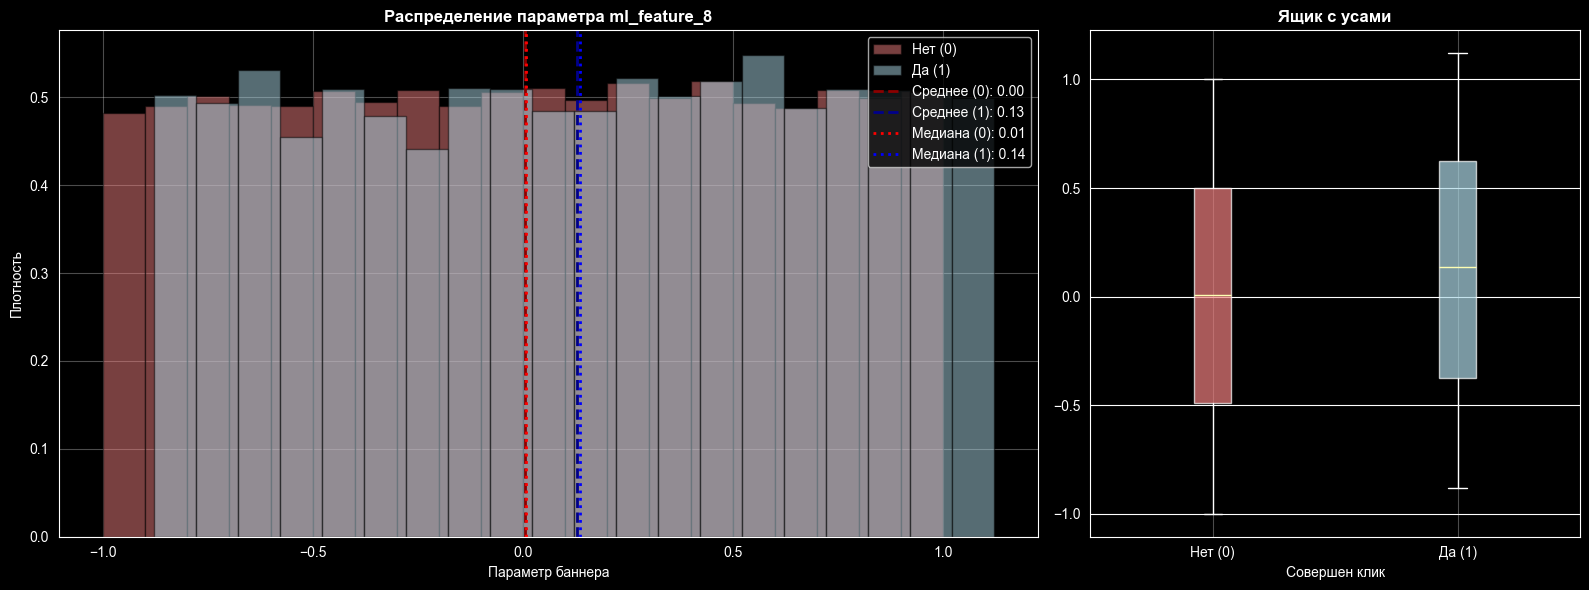

In [192]:
plot_distribution(df, 'click', 'ml_feature_8',
            'Распределение параметра ml_feature_8', 'Параметр баннера', bins=20)

Равномерное распределение. Класс `Да` смещен правее относитнльно 0.

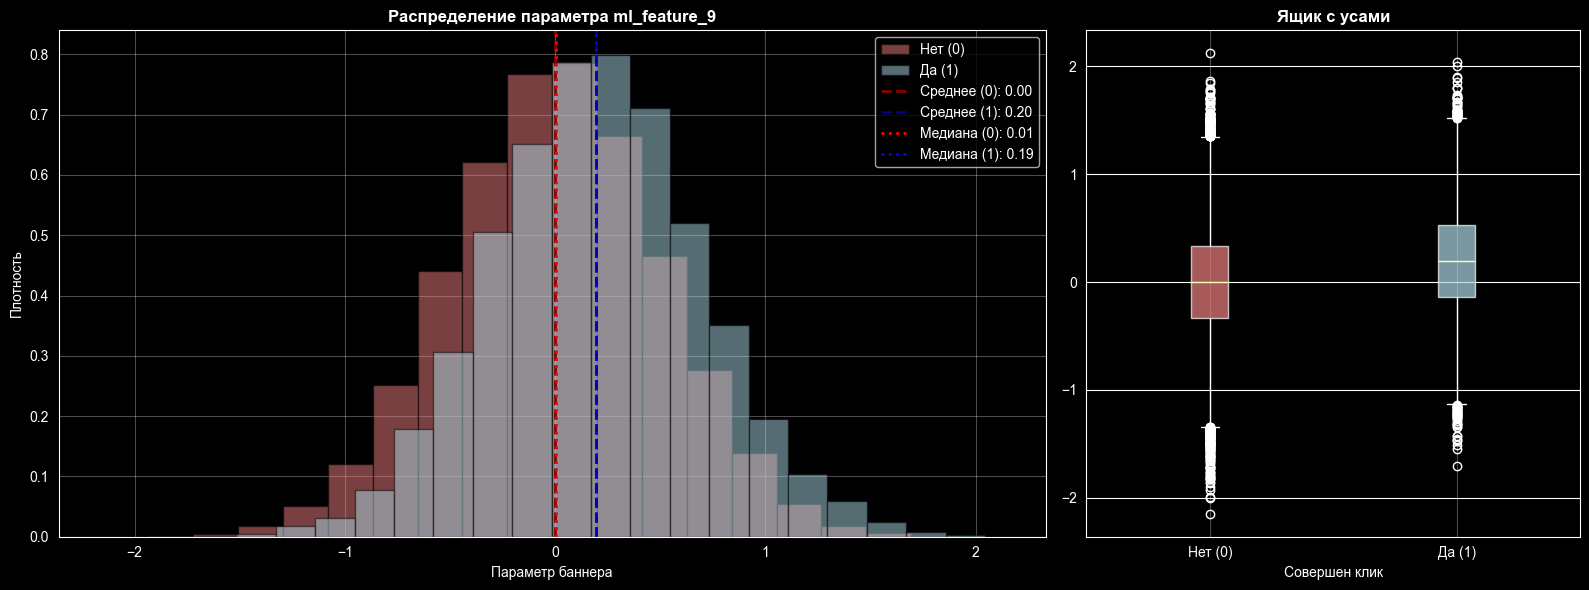

In [193]:
plot_distribution(df, 'click', 'ml_feature_9',
            'Распределение параметра ml_feature_9', 'Параметр баннера', bins=20)

Симметричное распределение для двух классов, но класс `Да` смещен относительно 0 вправо.

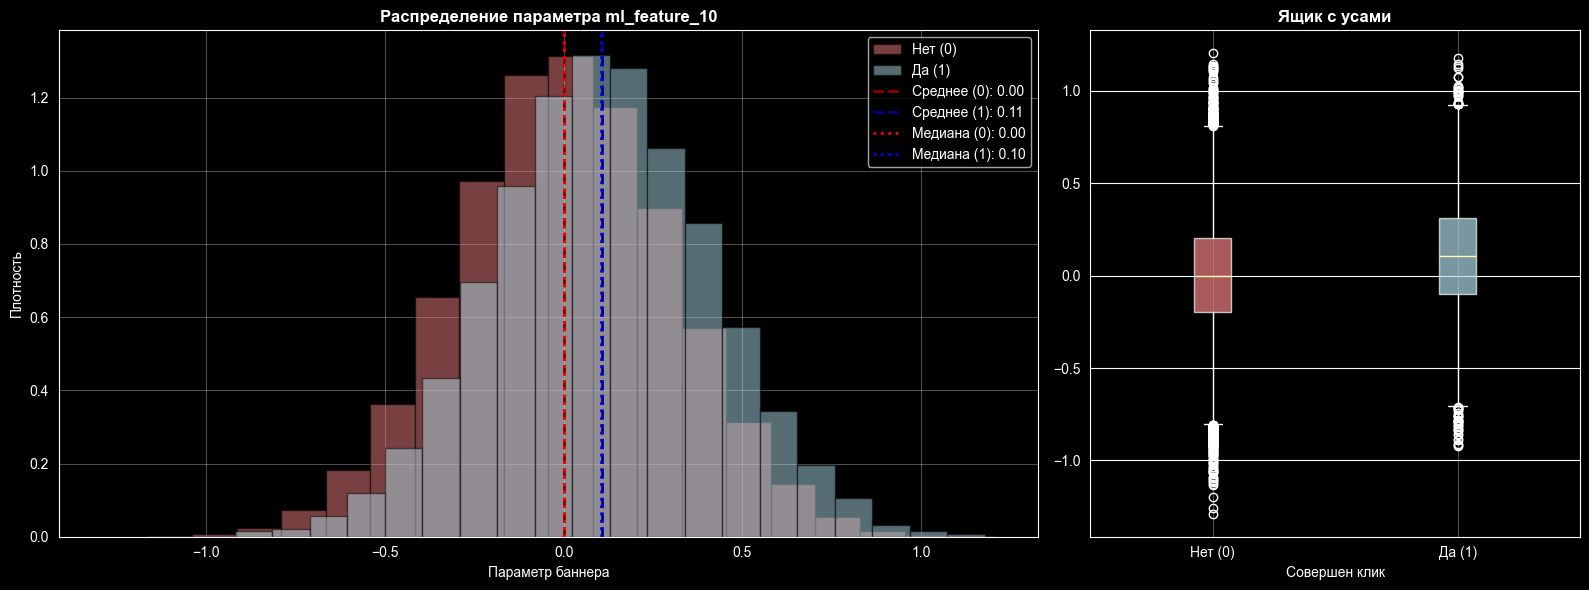

In [194]:
plot_distribution(df, 'click', 'ml_feature_10',
            'Распределение параметра ml_feature_10', 'Параметр баннера', bins=20)

Симметричное распределение для двух классов, но класс `Да` смещен относительно 0 вправо.


#### Оптимизация Датасета

In [195]:
# Класс оптимизации типов данных датафрейма
class DataFrameNormalizer:
    def __init__(self, df):
        self.df = df

    def run(self,
        to_int: list = None,
        to_float: list = None,
        to_category: list = None,
        to_date: list = None
    ) -> pd.DataFrame:
        original_df = self.df.copy()
        if to_int:
            self.to_int(to_int)
        if to_float:
            self.to_float(to_float)
        if to_category:
            self.to_category(to_category)
        if to_date:
            self.to_date(to_date)
        return pd.concat([
            original_df.dtypes.rename('До изменений'),
            self.df.dtypes.rename('После изменений')
        ], axis=1)

    def to_int(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='integer')

    def to_float(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='float')

    def to_category(self, columns: list) -> None:
        for column in columns:
            self.df[column] = df[column].astype('category')

    def to_date(self, columns: list) -> None:
        for column in columns:
            #self.df[column] = pd.to_datetime(self.df[column], unit='s')
            self.df[column] = pd.to_datetime(self.df[column].astype(str), format='%y%m%d%H')

In [196]:
categories = (
    'site_id',
    'site_domain',
    'site_category',
    'app_id',
    'app_domain',
    'app_category',
    'device_model',
    'ml_feature_2',
    'ml_feature_7',
    'device_id',
    'device_ip'
)
int64s = (
    'click',
#    'hour',
    'C1',
    'banner_pos',
    'device_type',
    'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'ml_feature_4',

)
float64s = (
    'ml_feature_1',
    'ml_feature_3',
    'ml_feature_5',
    'ml_feature_6',
    'ml_feature_8',
    'ml_feature_9',
    'ml_feature_10',
)
datetimes = (
    'hour',
)
DataFrameNormalizer(df).run(to_int=int64s, to_float=float64s, to_category=categories, to_date=datetimes)

,До изменений,После изменений
id,float64,float64
click,int64,int8
hour,int64,datetime64[us]
C1,int64,int16
banner_pos,int64,int8
site_id,str,category
site_domain,str,category
site_category,str,category
app_id,str,category
app_domain,str,category


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
"hour" интерпретирован неверно. Это не "все в 00 часов", а просто формат даты-времени "YYMMDDHH", который ты читаешь как обычное число. По нему нельзя делать такой вывод без преобразования в datetime

<div class="alert alert-info"> <b>Комментарии студента:</b> Спасибо, за замечание, я даже не подумал, что нужно попытаться перевести числа в datetime и получить временные ряды.</div>

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №2__

Здесь все еще смешаны настоящие числовые признаки и кодовые категориальные признаки.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.


In [197]:
df_sample = df.sample(n=1000, random_state=RANDOM_STATE)
df_sample['day'] = df_sample['hour'].dt.day
df_sample['weekday'] = df_sample['hour'].dt.weekday
df_sample['hour'] = df_sample['hour'].dt.hour

In [198]:
common_features = [
    'click',
    'day',
    'weekday',
    'hour',
    'site_id',
    'site_domain',
    'site_category',
    'app_id',
    'app_domain',
    'app_category',
    'device_model',
    'device_id',
#     'device_ip'
]
banner_features = ['banner_pos', 'C1'] + [f'C{feature}' for feature in range(14, 22)]
ml_features = [f'ml_feature_{feature}' for feature in range(1, 11)]


In [199]:
interval_columns = [
    'click', 
     'day', 'hour', 'weekday',
    'device_type',
    'device_conn_type', 'banner_pos',
    'C1',
    'C14', 
    'C15', 'C16', 'C17', 'C18',
    'C19', 'C20', 'C21', 
    'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 
    'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'
]
correlation_matrix = phik.phik_matrix(df_sample[common_features + banner_features + ml_features], interval_cols=interval_columns, bins=5, verbose=False)

/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 2924360. Are interval variables set correctly?
  warnings.warn(
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 2460496. Are interval variables set correctly?
  warnings.warn(
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 2553773. Are interval variables set correctly?
  warnings.warn(
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 8691540. Are interval variables set correctly?
  warnings.warn(
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 21630180. Are interval variables set correctly?
  warnings.

In [200]:
# Строим тепловую карту коэффициента phi_k
def plot_heatmap(corr_matrix):
    plt.figure(figsize=(12, 6))
    sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
               )
    plt.title('Тепловая карта коэффициента phi_k')

    plt.show()

Exception ignored in: <function ResourceTracker.__del__ at 0x1091b02c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes


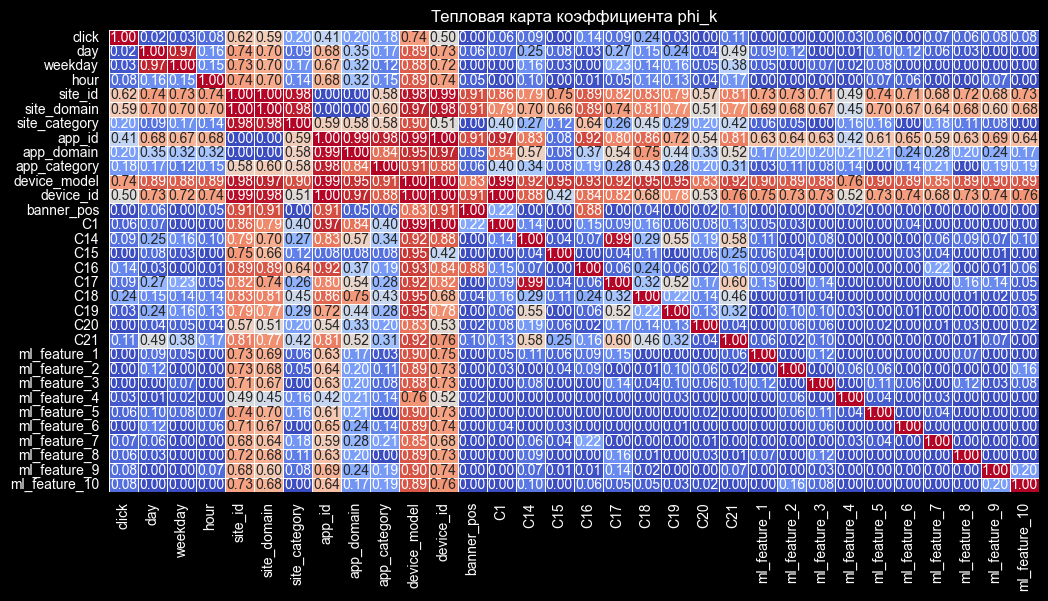

In [201]:
# Строим тепловую карту коэффициента phi_k
plot_heatmap(correlation_matrix)

In [202]:
# создаем список с параметрами с высокой корреляцией между признаками
high_corr_all_features = ['site_domain', 'app_domain', 'device_id']

In [203]:
click_corr = correlation_matrix['click'].drop('click')
threshold = 0.02
low_threshold = 0.02
high_corr_features = click_corr[click_corr >= threshold]
zero_corr_features = click_corr[click_corr < low_threshold]

In [204]:
print(f"Признаки с корреляцией > {threshold}:")
print(high_corr_features.sort_values(ascending=False).head(10))
print(f"Признаки с корреляцией <= {low_threshold}:")
print(zero_corr_features.sort_values(ascending=False))

Признаки с корреляцией > 0.02:
device_model     0.740501
site_id          0.618240
site_domain      0.590208
device_id        0.504654
app_id           0.409021
C18              0.244890
app_domain       0.202881
site_category    0.200616
app_category     0.184923
C16              0.137244
Name: click, dtype: float64
Признаки с корреляцией <= 0.02:
banner_pos      0.0
C15             0.0
C20             0.0
ml_feature_1    0.0
ml_feature_2    0.0
ml_feature_3    0.0
ml_feature_6    0.0
Name: click, dtype: float64


In [205]:
# создаем списки с параметров с высокой и низкой корреляцией с целевой переменной
high_corr_w_click_features = high_corr_features.index.tolist()
zero_corr_w_click_features = zero_corr_features.index.tolist()

Самая высокая корреляция с целевым признаком `click` у `device_model`, `site_id`, `site_domain`, `device_id` и `app_id`.
Отсутствует корреляцию у признаков `ml_feature_2`, `ml_feature_3` и `ml_feature_4`, эти признаки можно удалить.

Судя по матрице корреляции и по данным датафрейма, параметры `site_id` и `site_domain` дублируют друг друга и имеют коэффициент корреляции 1. Точно такая же ситуация с параметрами `app_id` и `app_domain`, `device_id` и `device_model`. Параметры `site_domain`, `app_domain` и `device_id` поместим в переменную для дальшейшего удаления.

In [206]:
# Создаем список с признаками для удаления
#df = df.drop(columns=['ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'site_domain', 'app_domain'])
features_to_drop = zero_corr_w_click_features + high_corr_all_features + ['device_ip', 'id']

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Как писал ранее, корреляция считается на всем датасете. Это утечка данных, если потом на основе этих расчетов удаляются признаки

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

И по результатам этого блока удаляются признаки 
    
    
    df = df.drop(columns=['ml_feature_2', 'ml_feature_3', 'ml_feature_4', 'site_domain', 'app_domain'])
    
Feature selection по всему датасету до split нельзя делать

<div class="alert alert-info"> <b>Комментарии студента:</b> Поместил фичи для дальнейшего удаления в отдельную переменную, чтобы удалить их в пайплайне.
Столкнулся с проблемой расчета матрицы корреляции на большом датасете с большим количеством уникальных значений в категориальных признаков, ничего лучше чем ограничить датасет и уменьшить количество бинов не придумал, но рассчет все равно занимает около 8 минут на моем ноутбуке.<br>
df_sample = df.sample(n=1000, random_state=RANDOM_STATE)<br>
Вопрос:<br>
- корректно ли так делать?<br>
- можно ли разбивать матрицу на две части по количеству параметров, для ускорения расчета матрицы?<br>
</div>

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

В процессе исследования данных выделен признак с сильной связью `device_model`, так же есть два признака со средней связью `site_domain` и`device_id` остальные признаки с низкой связью. При этом обнаружено, что у признаков группы site_id - site_domain, app_id - add_domain и device_model - device_type сильные связи внутри групп, что говорит нам о колинеарности и возможной нестабильности весов для целевой переменно. Избыточные фичи добавлены в переменную `features_to_drop`.

Наибольее значимые признаки для модели:
- device_model     0.74
- site_id          0.61
- site_domain      0.59
- device_id        0.50
- app_id           0.40

- Дальнейшие действия по предобработке данных:
Числовые признаки нужно масштабировать StandardScaler или MinMaxScaler.
Категориальные признаки с числом уникальных значений < 10 закодируем при помощи OneHotEncoder.
Все остальные категориальные признаки закодируем при помощи TargetEncoder.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Выводы делаешь с учетом утечки

<div class="alert alert-info"> <b>Комментарии студента:</b> Поправил вывод после пересчета корреляции.
</div>

## 3. Разделение данных на выборки


#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

In [207]:
# Отделим признаки и целевую переменную (churn)
X = df.drop(columns='click')
y = df['click']

In [208]:
# Выделим train_val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

In [209]:
print(f"Размер обучающей выборки: {X_train_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля положительного класса в train: {y_train_val.mean():.3f}")
print(f"Доля положительного класса в test: {y_test.mean():.3f}")

Размер обучающей выборки: (40000, 33)
Размер тестовой выборки: (10000, 33)
Доля положительного класса в train: 0.172
Доля положительного класса в test: 0.172


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Верно

## 4. Предобработка данных — построение пайплайнов





#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

In [210]:
#Создадим пайплайн для числовых признаков
num_features = [
    # 'hour',
    # 'device_type',
    # 'device_conn_type',
    # 'banner_pos',
    # 'C1',
    'C14',
    # 'C15',
    # 'C16',
    'C17',
    # 'C18',
    # 'C19',
    # 'C20',
    'C21',
    # 'ml_feature_1',
    # 'ml_feature_4',
    # 'ml_feature_5',
    # 'ml_feature_6',
    'ml_feature_8',
    'ml_feature_9',
    # 'ml_feature_10',
]

num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [211]:
#Создадим пайплайн для категориальных признаков
cat_onehot_features = [
    # 'C1',
    'C16',
    'C18',
    # 'ml_feature_7',
    'device_type',
    'device_conn_type'
]
cat_target_features = [
    'site_id',
    'site_category',
    'app_id',
    'app_category',
    'device_model',
]

cat_onehot_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])
cat_target_pipeline = Pipeline(steps=[
    ('encoder', TargetEncoder(smooth=10.0, target_type='binary',))
])

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

In [212]:
class DateTimeEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, datetime_col='hour'):
        self.datetime_col = datetime_col
        self.feature_names_ = ['day_sin', 'day_cos', 'weekday_sin', 'weekday_cos', 'hour_sin', 'hour_cos']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        dt = pd.to_datetime(X_copy[self.datetime_col])

        result = pd.DataFrame(index=X_copy.index)
        result['day_sin'] = np.sin(2 * np.pi * dt.dt.day / 31)
        result['day_cos'] = np.cos(2 * np.pi * dt.dt.day / 31)
        result['weekday_sin'] = np.sin(2 * np.pi * dt.dt.weekday / 7)
        result['weekday_cos'] = np.cos(2 * np.pi * dt.dt.weekday / 7)
        result['hour_sin'] = np.sin(2 * np.pi * dt.dt.hour / 24)
        result['hour_cos'] = np.cos(2 * np.pi * dt.dt.hour / 24)
        return result

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_

In [213]:
# hour_transformer = FunctionTransformer(
#     enhance_hour,
#     kw_args={'col': 'hour'},
#     feature_names_out=get_hour_feature_names
# )

hour_pipeline = Pipeline([
    ('enhance_hour', DateTimeEncoder()),
    ('scaler', StandardScaler())
])
hour_features = ['hour']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat_onehot', cat_onehot_pipeline, cat_onehot_features),
        ('cat_target', cat_target_pipeline, cat_target_features),
        ('hour', hour_pipeline, hour_features),
    ],
    remainder='drop',
    # verbose_feature_names_out=False
)


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
"hour" оставлен в числовых и масштабируется как непрерывный числовой признак

<div class="alert alert-info"> <b>Комментарии студента:</b> На хабре нашел статью по улучшению временных признаков, написано что если просто масштабировать циклические данные то модель не увидит, что расстояние между минимальным и максимальным значением такое же как между другими соседними. Попробывал реализовать это в проекте.<br>
Так же перенес категориальные фичи в нужные пайплайны.

</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 

Да, для EDA так делать допустимо: взять df.sample(...) и посчитать phi_k на подвыборке - нормальный технический компромисс, если полная матрица считается слишком долго.

## 5. Отбор признаков







#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

In [214]:
# Признаки с одним уникальным значением или меньше
constant_features = df.columns[df.nunique() <= 1].tolist()
features_to_drop += constant_features
print(f"Константные признаки (0 или 1 уникальное значение): {constant_features}")

Константные признаки (0 или 1 уникальное значение): []


Константных признаков в датасете нет.

In [215]:
# Удаляем числовые квази-константные признаки (threshold=0.90)
vs_quasi = VarianceThreshold(threshold=0.10)
numerical_columns = X_train_val.select_dtypes(include=[np.number]).columns
numerical_data = X_train_val[numerical_columns]
vs_quasi.fit(numerical_data)
quasi_num_cols = [col for col, keep in zip(numerical_columns, vs_quasi.get_support()) if not keep]

# Квази-константные категориальные признаки
quasi_cat_cols = [col for col in X_train_val.select_dtypes(include=['object']).columns
                  if X_train_val[col].value_counts(normalize=True).iloc[0] > 0.90]

# Объединяем
quasi_constant_cols = quasi_num_cols + quasi_cat_cols
features_to_drop += quasi_constant_cols
print("Квази-константные признаки для удаления:", quasi_constant_cols)

Квази-константные признаки для удаления: ['ml_feature_10']


In [216]:
#Удаляем квазиконстантные признаки
#X_train_val = X_train_val.drop(columns=features_to_drop + ['device_ip', 'id'])

In [217]:
df_train = X_train_val.copy()
df_train = df_train.drop(columns=features_to_drop)
df_train['click'] = y_train_val
x_train_sample = df_train.sample(random_state=RANDOM_STATE, n=10000)

In [218]:
x_train_sample.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 7323 to 14946
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   hour              10000 non-null  datetime64[us]
 1   C1                10000 non-null  int16         
 2   site_id           10000 non-null  category      
 3   site_category     10000 non-null  category      
 4   app_id            10000 non-null  category      
 5   app_category      10000 non-null  category      
 6   device_model      10000 non-null  category      
 7   device_type       10000 non-null  int8          
 8   device_conn_type  10000 non-null  int8          
 9   C14               10000 non-null  int16         
 10  C16               10000 non-null  int16         
 11  C17               10000 non-null  int16         
 12  C18               10000 non-null  int8          
 13  C19               10000 non-null  int16         
 14  C21               10000 non-null  i

In [219]:
interval_columns = [
    'click', 'device_type', 'device_conn_type', 'banner_pos', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'
]
correlation_matrix = phik.phik_matrix(x_train_sample, interval_cols=interval_columns)

/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable device_model is large: 1393. Are you sure this is not an interval variable? Analysis for pairs of variables including device_model can be slow.
  warnings.warn(
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 2460496. Are interval variables set correctly?
  warnings.warn(
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/phik/bivariate.py:255: UserWarning: Many cells: 2924360. Are interval variables set correctly?
  warnings.warn(


In [220]:
#Выводим топ 5 самых сильных и слабых признаков
phik_click_correlations_all = correlation_matrix['click'].drop('click')

phik_click = phik_click_correlations_all
print("--- Признаки с самой слабой связью среди  ---")
# Выводим 5 самых слабых оценочных признаков
print(phik_click.sort_values(ascending=False).tail(5).to_string(float_format="%.4f"))

print("\n--- Признаки с самой сильной связью среди оценок ---")
# Выводим 5 самых сильных оценочных признаков
print(phik_click.sort_values(ascending=False).head(5).to_string(float_format="%.4f"))


--- Признаки с самой слабой связью среди  ---
ml_feature_5   0.0856
device_type    0.0666
C1             0.0610
ml_feature_7   0.0272
ml_feature_4   0.0000

--- Признаки с самой сильной связью среди оценок ---
device_model   0.4696
site_id        0.4358
app_id         0.3238
C18            0.2508
C16            0.2007


In [221]:
# Найдем список признаков с корреляцией ниже 0.1
low_corr_features = phik_click[phik_click < 0.1].index.tolist()
features_to_drop += low_corr_features

In [222]:
# Удалим признаки с низкой корреляцией
# df = df.drop(columns=low_corr_features)
# X_train_val = X_train_val.drop(columns=features_to_drop)

В результате фильтрации был удален один квази-константный признак 'ml_feature_10' из за низкой вариативности.
А так же были удалены признаки с коэффициентом корреляции phik < 0.1.
['C1', 'device_type', 'C19', 'ml_feature_4', 'ml_feature_5', 'ml_feature_7']

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Снова все делается на полном df, а не на train
    
    
    vs_quasi.fit(numerical_data)
    correlation_matrix = phik.phik_matrix(df, ...)
    df = df.drop(columns=quasi_constant_cols)
    df = df.drop(columns=low_corr_features)

<div class="alert alert-info"> <b>Комментарии студента:</b> Теперь признаки удалены только из X_train_val.
</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 
Учтено

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

In [223]:
# X_train_val_processed = preprocessor.fit_transform(X_train_val, y_train_val)

estimator = LogisticRegression(solver='liblinear')
num_features_to_select = 20

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', RFE(
        estimator=LogisticRegression(solver='liblinear'),
        n_features_to_select=num_features_to_select, step=1)
    ),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Создаём объект RFE
# rfe_selector = RFE(estimator, n_features_to_select=num_features_to_select, step=1, verbose=0)

# Применяем отбор к данным
pipeline.fit(X_train_val, y_train_val)

# Получаем булев массив с отобранными признаками
# feature_names = preprocessor.get_feature_names_out()
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

selected_features = feature_names[pipeline.named_steps['selector'].support_]
print(f'\nВыбранные признаки RFE ({num_features_to_select}): {selected_features}')

# rfe_selector.ranking_ - массив, показывающий ранг признаков (1 - наиболее важные, удалённые - больше 1)
# print(f'Ранжирование признаков RFE: {rfe_selector.ranking_}')
print(f'Ранжирование признаков RFE: {pipeline.named_steps['selector'].ranking_}')

# for feature, rank in zip(feature_names, rfe_selector.ranking_):
for feature, rank in zip(feature_names, pipeline.named_steps['selector'].ranking_):
    print(f'Признак: {feature}, Ранг: {rank}')


Выбранные признаки RFE (20): ['num__ml_feature_9' 'cat_onehot__C16_36' 'cat_onehot__C16_50'
 'cat_onehot__C16_90' 'cat_onehot__C16_250' 'cat_onehot__C16_480'
 'cat_onehot__C18_1' 'cat_onehot__device_type_0'
 'cat_onehot__device_type_1' 'cat_onehot__device_type_4'
 'cat_onehot__device_type_5' 'cat_onehot__device_conn_type_0'
 'cat_onehot__device_conn_type_2' 'cat_onehot__device_conn_type_3'
 'cat_onehot__device_conn_type_5' 'cat_target__site_id'
 'cat_target__site_category' 'cat_target__app_id'
 'cat_target__app_category' 'cat_target__device_model']
Ранжирование признаков RFE: [ 8  9 12  6  1 10  1  1  1  1  5  1 11  7  3  1  4  2  1  1  1  1  1  1
  1  1  1  1  1  1  1 18 13 17 15 14 16]
Признак: num__C14, Ранг: 8
Признак: num__C17, Ранг: 9
Признак: num__C21, Ранг: 12
Признак: num__ml_feature_8, Ранг: 6
Признак: num__ml_feature_9, Ранг: 1
Признак: cat_onehot__C16_20, Ранг: 10
Признак: cat_onehot__C16_36, Ранг: 1
Признак: cat_onehot__C16_50, Ранг: 1
Признак: cat_onehot__C16_90, Ранг: 1

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

In [224]:
# Оставшиеся признаки в модели после методов фильтрации и обертки
display(selected_features)

array(['num__ml_feature_9', 'cat_onehot__C16_36', 'cat_onehot__C16_50',
       'cat_onehot__C16_90', 'cat_onehot__C16_250', 'cat_onehot__C16_480',
       'cat_onehot__C18_1', 'cat_onehot__device_type_0',
       'cat_onehot__device_type_1', 'cat_onehot__device_type_4',
       'cat_onehot__device_type_5', 'cat_onehot__device_conn_type_0',
       'cat_onehot__device_conn_type_2', 'cat_onehot__device_conn_type_3',
       'cat_onehot__device_conn_type_5', 'cat_target__site_id',
       'cat_target__site_category', 'cat_target__app_id',
       'cat_target__app_category', 'cat_target__device_model'],
      dtype=object)

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


Есть явный список выбранных признаков после RFE

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №2__

rfe_selector у тебя обучается отдельно заранее: X_train_val_processed = preprocessor.fit_transform(X_train_val, y_train_val)
rfe_selector.fit(X_train_val_processed, y_train_val)
    
    
После этого тот же уже обученный rfe_selector вставляется в Pipeline для cross_validate и GridSearchCV. Это утечка. Отбор признаков должен происходить внутри каждого фолда заново, а не быть заранее обученным на всей train_val

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №2__

ты вставил в pipeline уже заранее обученный selector

<div class="alert alert-info"> <b>Комментарии студента:</b> Заменил селектор на новый экземпляр класса
</div>

## 6. Обучение базовой модели

### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

In [225]:
# Датафрейм для всех оценок моделей
model_results_df = pd.DataFrame({
    'model': [],
    'PR_AUC': [],
    'PR_AUC dev': [],
    'LogLos': [],
    'LogLos dev': [],
    'Brier': [],
    'Brier dev': [],
})

In [226]:
#Кроссвалидация дамми модели
dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Метрики для оценки
scoring = ['average_precision', 'neg_log_loss', 'neg_brier_score']
start_time = time()
cv_res = cross_validate(dummy_pipeline, X_train_val, y_train_val, scoring=scoring, cv=cv)
end_time = time()

def model_metric(cv_result, tmp_pipeline, time_spent, tmp_scoring, modificator=None):

    model_name = tmp_pipeline.named_steps['classifier'].__class__.__name__
    if modificator:
        model_name = model_name + ' ' + modificator
    print(f'\n--- Средние Метрики {model_name} Модели (CV) ---')
    res_metrics = {}
    res_metrics['model'] = model_name
    metric_map = {
        'average_precision': 'PR_AUC',
        'log_loss': 'LogLos',
        'brier_score': 'Brier',
    }
    for metric in tmp_scoring:

        # if f'test_{metric}' not in cv_result:
        #     continue
        mean_value = cv_result[f'test_{metric}'].mean()
        std_value = cv_result[f'test_{metric}'].std()
        if metric.startswith('neg_'):
            metric = metric.replace('neg_', '')
            mean_value = -mean_value
        metric = metric_map[metric]

        print(f'{metric}: {mean_value:.3f} (±{std_value*2:.3f})')
        res_metrics[metric] = f'{mean_value:.3f}'
        res_metrics[f'{metric} dev'] = f'±{std_value*2:.3f}'


    tmp_df = pd.DataFrame([res_metrics])
    print(f'Затрачено времени: {time_spent:.2f} сек.')
    return tmp_df

dummy_metrics = model_metric(cv_res, dummy_pipeline, end_time - start_time, scoring)
model_results_df = pd.concat([model_results_df, dummy_metrics], ignore_index=True)
dummy_metrics


--- Средние Метрики DummyClassifier Модели (CV) ---
PR_AUC: 0.172 (±0.000)
LogLos: 6.201 (±0.004)
Brier: 0.172 (±0.000)
Затрачено времени: 0.26 сек.


,model,PR_AUC,PR_AUC dev,LogLos,LogLos dev,Brier,Brier dev
0,DummyClassifier,0.172,±0.000,6.201,±0.004,0.172,±0.000


### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.


In [227]:
#Кроссвалидация базовой модели
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # ('selector', RFE(LogisticRegression(solver='liblinear'), n_features_to_select=num_features_to_select)),
    #('selector', rfe_selector),
    ('selector', RFE(
        estimator=LogisticRegression(solver='liblinear'),
        n_features_to_select=num_features_to_select, step=1)
    ),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])
start_time = time()
logreg_cv_res = cross_validate(
    logreg_pipeline,
    X_train_val,
    y_train_val,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    return_estimator=True
)
end_time = time()

logreg_metrics = model_metric(logreg_cv_res, logreg_pipeline, end_time - start_time, scoring)
model_results_df = pd.concat([model_results_df, logreg_metrics], ignore_index=True)
logreg_metrics


--- Средние Метрики LogisticRegression Модели (CV) ---
PR_AUC: 0.378 (±0.018)
LogLos: 0.406 (±0.003)
Brier: 0.127 (±0.001)
Затрачено времени: 1.57 сек.


,model,PR_AUC,PR_AUC dev,LogLos,LogLos dev,Brier,Brier dev
0,LogisticRegression,0.378,±0.018,0.406,±0.003,0.127,±0.001


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Логрегрессия оценивается уже не на честной схеме, потому что selector был обучен заранее на всей train_val

<div class="alert alert-info"> <b>Комментарии студента:</b> Заменил селектор на общий. Не уверен, я что правильно понял комментарий.
</div>

### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`


In [228]:
#Кроссвалидация базовой модели
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # ('selector', rfe_selector),
    ('selector', RFE(
        estimator=LogisticRegression(solver='liblinear'),
        n_features_to_select=num_features_to_select, step=1)
    ),
    # ('selector', RFE(LogisticRegression(solver='liblinear'), n_features_to_select=num_features_to_select)),
    ('classifier', SVC(
        kernel='linear',
        probability=False,
        random_state=RANDOM_STATE,
    ))
])

start_time = time()
svc_cv_res = cross_validate(
    svc_pipeline,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_estimator=True
)
end_time = time()

def add_proba_metrics(cv_res, X_tmp, y_tmp):
    pr_auc = []
    brier = []
    loglos = []
    for estimator in cv_res['estimator']:
        proba = 1 / (1 + np.exp(-estimator.decision_function(X_tmp)))
        pr_auc.append(average_precision_score(y_tmp, proba))
        brier.append(brier_score_loss(y_tmp, proba))
        loglos.append(log_loss(y_tmp, proba))

    cv_res['test_average_precision'] = np.array(pr_auc)
    cv_res['test_brier_score'] = np.array(brier)
    cv_res['test_log_loss'] = np.array(loglos)
    return cv_res

svc_cv_res = add_proba_metrics(svc_cv_res, X_train_val, y_train_val)
svc_metrics = model_metric(svc_cv_res, svc_pipeline, end_time - start_time, ['average_precision', 'brier_score', 'log_loss'])
model_results_df = pd.concat([model_results_df, svc_metrics], ignore_index=True)
svc_metrics

Exception ignored in: <function ResourceTracker.__del__ at 0x107cd82c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1074b42c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3


--- Средние Метрики SVC Модели (CV) ---
PR_AUC: 0.331 (±0.097)
Brier: 0.152 (±0.000)
LogLos: 0.485 (±0.000)
Затрачено времени: 5.42 сек.


,model,PR_AUC,PR_AUC dev,Brier,Brier dev,LogLos,LogLos dev
0,SVC,0.331,±0.097,0.152,±0.000,0.485,±0.000


### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

Базовая модель `LogisticRegression` значительно лучше чем `Dummy` предсказывает по ключевой метрике `pr_auc` 0.378 (±0.018) против  0.172 (±0.000).

Базовая модель `SVC` показывает немного лучший результат, чем `LogisticRegression`но предсказания менее стабильны, по основной метрике для задачи классификации с дисбалансом классов LogReg показывает 0.378 (±0.018), тогда как SVC показывает худший результат 0.380 (±0.011).

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
в одном месте для SVC указано "0.383", а в выводе написано "0.353"

<div class="alert alert-info"> <b>Комментарии студента:</b> изменил выводы после пересчета и изменения пайплайна.
</div>

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №2__

    
Метрики для LogisticRegression сейчас не являются честными из-за заранее обученного rfe_selector
    
---    
    
    
    
Для SVC проблема еще сильнее:
    
    
    * ты делаешь cross_validate(..., return_estimator=True)
    * потом считаешь decision_function(X_train_val) для всего X_train_val
    * то есть оцениваешь фолдовую модель не на ее валидационном фолде, а на всей train_val
    
    
Это снова искажение оценки. Поэтому текущим PR-AUC, Brier, LogLoss для SVC доверять нельзя

<div class="alert alert-info"> <b>Комментарии студента:</b> поменял предобученый экземпляр на новый.
</div>

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией






#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.


In [229]:
# Гиперпараметры для LogReg
param_grid_logreg = [
    {
        'classifier__l1_ratio': [0],
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['saga', 'lbfgs'],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [1000]
    },
    {
        'classifier__l1_ratio': [1],
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['saga', 'liblinear'],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [1000]
    },
    {
        'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'classifier__C': [0.1, 1, 10],
        'classifier__solver': ['saga'],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [1000]
    }
]

In [230]:
# Гиперпараметры для SVC
param_grid_svc = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier__kernel': ['poly'],
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 'auto'],
        'classifier__degree': [2, 3],
        'classifier__coef0': [0.0, 0.5, 1.0],
        'classifier__class_weight': ['balanced']
    },
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 'auto'],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier__kernel': ['sigmoid'],
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 'auto'],
        'classifier__coef0': [0.0, 0.5, 1.0],
        'classifier__class_weight': [None, 'balanced']
    }
]

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

In [231]:
# GridSearch для LogReg
logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid_logreg,
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

In [232]:
# Поиск лучших гиперпараметров для LogReg
logreg_grid.fit(X_train_val, y_train_val)

logreg_best_params = logreg_grid.best_params_
logreg_best_estimator = logreg_grid.best_estimator_
logreg_best_score = round(logreg_grid.best_score_, 3)

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", logreg_best_params)
print("Лучшая модель:", logreg_best_estimator)
print("Лучший средний результат accuracy на кросс-валидации:", logreg_best_score)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x1074c42c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Лучшие гиперпараметры: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.7, 'classifier__max_iter': 1000, 'classifier__solver': 'saga'}
Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['C14', 'C17', 'C21',
                                                   'ml_feature_8',
                                                   'ml_feature_9']),
                                                 ('cat_onehot',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),


In [233]:
# GridSearch для SVC
svc_grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid_svc,
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1
)

In [234]:
# Поиск лучших гиперпараметров для SVC
svc_grid.fit(X_train_val, y_train_val)

svc_best_params = svc_grid.best_params_
svc_best_estimator = svc_grid.best_estimator_
svc_best_score = round(svc_grid.best_score_, 3)

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", svc_best_params)
print("Лучшая модель:", svc_best_estimator)
print("Лучший средний результат accuracy на кросс-валидации:", svc_best_score)

Fitting 3 folds for each of 90 candidates, totalling 270 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x107e142c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/Users/maksimsesemov/PycharmProjects/DS_SVM_Sprint_12/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x1074d

Лучшие гиперпараметры: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear'}
Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['C14', 'C17', 'C21',
                                                   'ml_feature_8',
                                                   'ml_feature_9']),
                                                 ('cat_onehot',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

In [235]:
# Создадим датафреймы с результатами обучения
logreg_results_df = pd.DataFrame(logreg_grid.cv_results_)
logreg_results_df['model'] = LogisticRegression

svc_results_df = pd.DataFrame(svc_grid.cv_results_)
svc_results_df['model'] = SVC

In [236]:
# Выводим 10 лучших моделей
results_df = pd.concat([logreg_results_df, svc_results_df], ignore_index=True)
results_df.sort_values(by='mean_test_score', ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__class_weight,param_classifier__l1_ratio,param_classifier__max_iter,param_classifier__solver,params,...,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,model,param_classifier__kernel,param_classifier__coef0,param_classifier__degree,param_classifier__gamma
47,1.874567,0.247777,0.024825,0.000834,10.0,NaN,0.7,1000.0,saga,"{'classifier__C': 10, 'classifier__class_weigh...",...,0.387298,0.364523,0.379645,0.010693,1,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
6,1.736736,0.311393,0.027277,0.006041,1.0,balanced,0.0,1000.0,saga,"{'classifier__C': 1, 'classifier__class_weight...",...,0.386343,0.363870,0.378756,0.010526,2,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
16,1.859137,0.384516,0.028597,0.007694,1.0,NaN,1.0,1000.0,saga,"{'classifier__C': 1, 'classifier__class_weight...",...,0.387250,0.359487,0.377917,0.013033,3,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
17,3.365509,0.465327,0.022812,0.001192,1.0,NaN,1.0,1000.0,liblinear,"{'classifier__C': 1, 'classifier__class_weight...",...,0.387429,0.358902,0.377906,0.013437,4,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
38,1.772008,0.351486,0.032230,0.009319,1.0,NaN,0.9,1000.0,saga,"{'classifier__C': 1, 'classifier__class_weight...",...,0.387522,0.358951,0.377874,0.013381,5,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
21,2.676848,0.968106,0.038599,0.009988,10.0,NaN,1.0,1000.0,liblinear,"{'classifier__C': 10, 'classifier__class_weigh...",...,0.387078,0.359357,0.377854,0.013079,6,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
46,3.050969,0.183239,0.034522,0.004385,10.0,NaN,0.5,1000.0,saga,"{'classifier__C': 10, 'classifier__class_weigh...",...,0.386641,0.359445,0.377728,0.012929,7,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
37,1.493319,0.278455,0.026962,0.001739,1.0,NaN,0.7,1000.0,saga,"{'classifier__C': 1, 'classifier__class_weight...",...,0.387646,0.358565,0.377670,0.013513,8,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
9,1.578772,0.371818,0.049754,0.014913,10.0,NaN,0.0,1000.0,lbfgs,"{'classifier__C': 10, 'classifier__class_weigh...",...,0.387261,0.358853,0.377649,0.013292,9,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN
48,2.620392,0.593153,0.029193,0.001944,10.0,NaN,0.9,1000.0,saga,"{'classifier__C': 10, 'classifier__class_weigh...",...,0.386347,0.359506,0.377641,0.012826,10,<class 'sklearn.linear_model._logistic.Logisti...,NaN,NaN,NaN,NaN


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Используется "GridSearchCV"

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №2__

    
В GridSearchCV ты снова передаешь pipeline с тем же заранее обученным rfe_selector. Значит, подбор гиперпараметров все еще идет по нечестной схеме


<div class="alert alert-info"> <b>Комментарии студента:</b> Переделал, чтобы во всех пайплайнах был новый экземпляр RFE.
</div>

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

In [237]:
# Извлекаем лучшие гиперпараметры из общего датафрейма
best_params = results_df.sort_values(by='mean_test_score', ascending=False).head(1)['params'].values[0]
model_params = {k.replace('classifier__', ''): v
               for k, v in best_params.items()}
display(model_params)

{'C': 10,
 'class_weight': None,
 'l1_ratio': 0.7,
 'max_iter': 1000,
 'solver': 'saga'}

In [238]:
# Обучаем лучшую модель на всей обучающей выборке
best_model_class = results_df.sort_values(by='mean_test_score', ascending=False).head(1)['model'].values[0]

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # ('selector', rfe_selector),
    ('selector', RFE(
        estimator=LogisticRegression(solver='liblinear'),
        n_features_to_select=num_features_to_select, step=1)
    ),
    ('classifier', best_model_class(
        **model_params, #probability=True
    ))
])
best_pipeline.fit(X_train_val, y_train_val)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [239]:
# Обучаем лучшую svc модель на всей обучающей выборке
svc_model_params = {k.replace('classifier__', ''): v
               for k, v in svc_best_params.items()}
best_svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # ('selector', rfe_selector),
    ('selector', RFE(
        estimator=LogisticRegression(solver='liblinear'),
        n_features_to_select=num_features_to_select, step=1)
    ),
    ('classifier', SVC(
        **svc_model_params, probability=True
    ))
])
best_svc_pipeline.fit(X_train_val, y_train_val)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.


In [240]:
# Метрики по LogLos
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

logloss = log_loss(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print("Результаты модели на всей обучающей выборке:")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Оценка Бриера: {brier:.3f}")
print(f"Log Loss: {logloss:.3f}")

Результаты модели на всей обучающей выборке:
PR-AUC: 0.353
Оценка Бриера: 0.129
Log Loss: 0.415


In [241]:
# Метрики по SVM
y_pred_proba = best_svc_pipeline.predict_proba(X_test)[:, 1]

logloss = log_loss(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print("Результаты модели на всей обучающей выборке:")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Оценка Бриера: {brier:.3f}")
print(f"Log Loss: {logloss:.3f}")

Результаты модели на всей обучающей выборке:
PR-AUC: 0.348
Оценка Бриера: 0.130
Log Loss: 0.415


#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

In [242]:
# Вывод весов в порядке убывания
def get_model_weights(estimator):
    weights = estimator.named_steps['classifier'].coef_[0]
    feature_names = estimator.named_steps['preprocessor'].get_feature_names_out()

    # Применяем отбор признаков (если есть selector)
    if 'selector' in estimator.named_steps:
        selected_indexes = estimator.named_steps['selector'].get_support()
        feature_names = feature_names[selected_indexes]
    weight_df = pd.DataFrame({
        'Признак': feature_names,
        'Вес': np.abs(weights)
    })
    return weight_df.sort_values(by='Вес', ascending=False)
get_model_weights(best_pipeline).head(10)

,Признак,Вес
17,cat_target__app_id,9.129113
15,cat_target__site_id,6.016480
18,cat_target__app_category,4.663014
19,cat_target__device_model,2.002249
5,cat_onehot__C16_320,1.329682
14,cat_onehot__device_conn_type_5,1.320044
3,cat_onehot__C16_90,1.116944
6,cat_onehot__C18_1,0.831460
1,cat_onehot__C16_36,0.763668
16,cat_target__site_category,0.679662


Среди отобраных 15 признаков наибольшее влияние оказывают имеют 5 признаков:
- cat_target__app_id	    8.84
- cat_target__site_id	    6.03
- cat_target__app_category	4.46
- cat_onehot__device_conn_type_5		3.22
- cat_onehot__device_conn_type_0		1.92

Самое большое влияние оказали app_ip, site_id, app_cat. Что примечательно все параметры относятся к категориальным параметрам.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №2__



Финальная модель снова использует тот же заранее обученный rfe_selector

<div class="alert alert-info"> <b>Комментарии студента:</b> Переделал, в финальных пайплайнах теперь новые экземпляры RFE.
</div>

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

In [243]:
#Расчет калибровок для LogReg и SVC
def sigmoid_numpy(x):
    return 1 / (1 + np.exp(-x))

svc_raw_scores = svc_grid.best_estimator_.decision_function(X_train_val)

# LogReg
prob_true_lr, prob_pred_lr = calibration_curve(
    y_train_val,
    logreg_grid.best_estimator_.predict_proba(X_train_val)[:,1],
    n_bins=10
)

# SVM
prob_true_svm, prob_pred_svm = calibration_curve(
    y_train_val,
    sigmoid_numpy(svc_raw_scores),
    n_bins=10
)

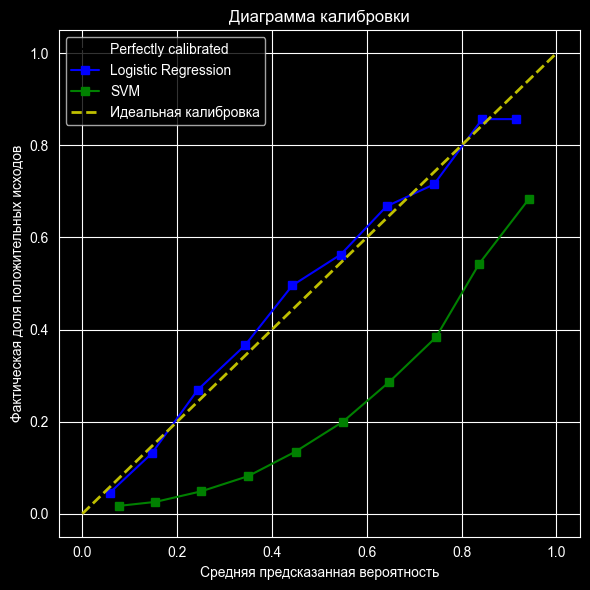

In [244]:
# Графики калибровок
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay(prob_true_lr, prob_pred_lr, y_train_val).plot(ax=ax, label='Logistic Regression', color='blue')
CalibrationDisplay(prob_true_svm, prob_pred_svm, y_train_val).plot(ax=ax, label='SVM', color='green')
plt.plot([0, 1], [0, 1], 'y--', linewidth=2, label='Идеальная калибровка',)

plt.title("Диаграмма калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

LogisticRegression откалибрована близко к идеальной линии, SVC излишне переоценивает вероятность во всем диапазоне значений. SVC неоткалибрована.

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!


In [245]:
# Разделяем выборку для калибровки и обучения
X_train, X_calib, y_train, y_calib = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train_val
)
print(f"Размер calib выборки: {X_calib.shape}")
print(f"Доля положительного класса в calib: {y_calib.mean():.3f}")

Размер calib выборки: (10000, 33)
Доля положительного класса в calib: 0.172


In [246]:
#Обучение лучней модели только на train выборке
best_svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    # ('selector', rfe_selector),
    ('selector', RFE(
        estimator=LogisticRegression(solver='liblinear'),
        n_features_to_select=num_features_to_select, step=1)
    ),
    ('classifier', SVC(
        **svc_model_params, probability=True
    ))
])
best_svc_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [247]:
# "Замораживаем" модель
# frozen_svm = FrozenEstimator(svc_best_estimator)
frozen_svm = FrozenEstimator(best_svc_pipeline)

# Калибруем с помощью isotonic
svm_calibrated = CalibratedClassifierCV(
    frozen_svm,
    method='isotonic'
)
svm_calibrated.fit(X_calib, y_calib)

# Получаем вероятности на тестовой выборке
p_raw = best_svc_pipeline.predict_proba(X_test)[:, 1]
p_calibrated = svm_calibrated.predict_proba(X_test)[:, 1]

In [248]:
print("\nПримеры вероятностей:")
for i in range(5):
    print(f"Объект {i+1}: raw={p_raw[i]:.3f}, calibrated={p_calibrated[i]:.3f}")


Примеры вероятностей:
Объект 1: raw=0.346, calibrated=0.323
Объект 2: raw=0.238, calibrated=0.274
Объект 3: raw=0.061, calibrated=0.042
Объект 4: raw=0.494, calibrated=0.491
Объект 5: raw=0.233, calibrated=0.240


In [249]:
# # "Замораживаем" модель
# logreg_frozen_svm = FrozenEstimator(logreg_best_estimator)
#
# # Калибруем с помощью isotonic
# logreg_calibrated = CalibratedClassifierCV(
#     logreg_frozen_svm,
#     method='isotonic'
# )
# logreg_calibrated.fit(X_calib, y_calib)
#
# # Получаем вероятности на тестовой выборке
# p_raw = logreg_best_estimator.predict_proba(X_test)[:, 1]
# p_calibrated = logreg_calibrated.predict_proba(X_test)[:, 1]

In [250]:
# print("\nПримеры вероятностей:")
# for i in range(5):
#     print(f"Объект {i+1}: raw={p_raw[i]:.3f}, calibrated={p_calibrated[i]:.3f}")

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

In [251]:
# функции подсчета ECE и MCE
def calculate_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    n = len(y_true)
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            ece += np.abs(bin_conf - bin_acc) * np.sum(mask)
    return ece / n

def calculate_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    max_error = 0
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            max_error = max(max_error, np.abs(bin_conf - bin_acc))
    return max_error

In [252]:
models = {
'LogReg_raw': logreg_grid.best_estimator_,
# 'LogReg_calib': logreg_calibrated,
'SVM_raw': svc_grid.best_estimator_,
'SVM_calib': svm_calibrated
}

In [253]:
def calculate_metrics(X_tmp, y_tmp, models_tmp):
    scoring_f = {'average_precision': 'average_precision'}
    results_list = []
    N_samples = len(y_tmp)
    print("--- Запуск кросс-валидации ---")

    for name, est in models_tmp.items():
        start_time = time()
        print(f"Оценка модели: {name}...", end=' ')

        cv_res = cross_validate(
            est, X_tmp, y_tmp,
            scoring=scoring_f,
            cv=cv,
            n_jobs=-1,
            return_estimator=True
        )

        new_row = {
            'model': name,
            **{f'{m}_mean': cv_res[f'test_{m}'].mean() for m in scoring_f},
            **{f'{m}_std':  cv_res[f'test_{m}'].std()  for m in scoring_f},
        }

        # Генерация OOF предсказаний
        oof_probs = np.zeros(N_samples)

        for i, (train_idx, test_idx) in enumerate(cv.split(X_tmp, y_tmp)):
            estimator = cv_res['estimator'][i]

            if name in ['SVM_raw', 'SVM_base']:
                raw_scores = estimator.decision_function(X_tmp.iloc[test_idx])
                prob_fold = sigmoid_numpy(raw_scores)
            else:
                prob_fold = estimator.predict_proba(X_tmp.iloc[test_idx])[:, 1]

            oof_probs[test_idx] = prob_fold

        # Brier, ECE, MCE на OOF
        oof_brier = brier_score_loss(y_tmp, oof_probs)
        oof_ece = calculate_ece(y_tmp, oof_probs)
        oof_mce = calculate_mce(y_tmp, oof_probs)
        new_row['PR-AUC'] = round(average_precision_score(y_tmp, oof_probs), 3)
        new_row['Brier'] = round(oof_brier, 3)
        new_row['ECE'] = round(oof_ece, 3)
        new_row['MCE'] = round(oof_mce, 3)

        results_list.append(new_row)

        end_time = time()
        print(f"Готово за {end_time - start_time:.2f} сек.")

    results_df = pd.DataFrame(results_list)

    display_cols = ['model', 'PR-AUC', 'Brier', 'ECE', 'MCE']
    return results_df[display_cols].sort_values(by=['PR-AUC', 'Brier', 'MCE', 'ECE'], ascending=False)

calculate_metrics(X_train_val, y_train_val, models)

--- Запуск кросс-валидации ---
Оценка модели: LogReg_raw... Готово за 2.16 сек.
Оценка модели: SVM_raw... Готово за 17.28 сек.
Оценка модели: SVM_calib... Готово за 12.95 сек.


,model,PR-AUC,Brier,ECE,MCE
2,SVM_calib,0.403,0.123,0.001,0.159
0,LogReg_raw,0.376,0.127,0.004,0.313
1,SVM_raw,0.370,0.213,0.278,0.398


In [254]:
# LogReg calibrated
# prob_true_logreg_calib, prob_pred_logreg_calib = calibration_curve(
#     y_train_val,
#     logreg_calibrated.predict_proba(X_train_val)[:,1],
#     n_bins=10
# )

# SVM calibrated
prob_true_svm_calib, prob_pred_svm_calib = calibration_curve(
    y_train_val,
    svm_calibrated.predict_proba(X_train_val)[:,1],
    n_bins=10
)

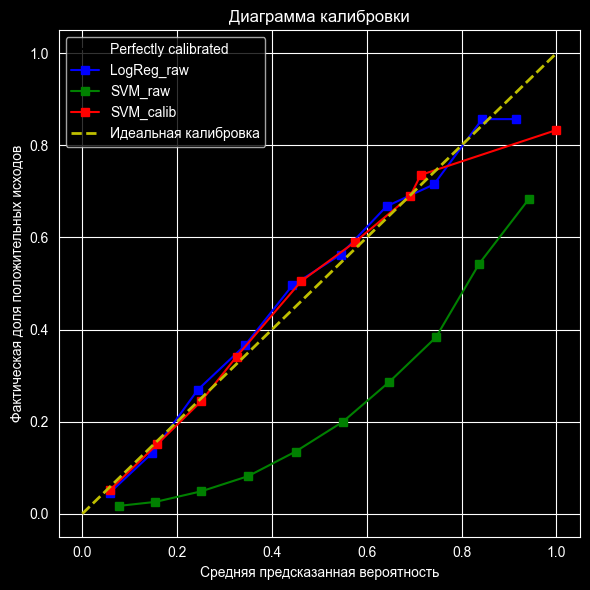

In [255]:
# Графики калибровок до и после
fig, ax1 = plt.subplots(figsize=(6, 6))
CalibrationDisplay(prob_true_lr, prob_pred_lr, y_train_val).plot(ax=ax1, label='LogReg_raw', color='blue')
# CalibrationDisplay(prob_true_logreg_calib, prob_pred_logreg_calib, y_train_val).plot(ax=ax1, label='LogReg_calib', color='purple')
CalibrationDisplay(prob_true_svm, prob_pred_svm, y_train_val).plot(ax=ax1, label='SVM_raw', color='green')
CalibrationDisplay(prob_true_svm_calib, prob_pred_svm_calib, y_train_val).plot(ax=ax1, label='SVM_calib', color='red')
ax1.plot([0, 1], [0, 1], 'y--', linewidth=2, label='Идеальная калибровка',)
# ax2.plot([0, 1], [0, 1], 'y--', linewidth=2, label='Идеальная калибровка',)

ax1.set_title("Диаграмма калибровки")
ax1.set_xlabel("Средняя предсказанная вероятность")
ax1.set_ylabel("Фактическая доля положительных исходов")
# ax2.set_title("Диаграмма калибровки")
# ax2.set_xlabel("Средняя предсказанная вероятность")
# ax2.set_ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

После калибровки модели SVM, калибровки от 0 до 0.7 показывает близкую к идеальной калиброку, но от 0.7 до 1.0 модель излишне оптимистична.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Лучше выбрать одну финальную модель, откалибровать именно ее и дальше уже только ее оценивать и сохранять

<div class="alert alert-info"> <b>Комментарии студента:</b> оставил только SVM
</div>

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №2__

    
Здесь еще одна критичная проблема. Ты делаешь:
    
    * svc_best_estimator после GridSearchCV на всей X_train_val
    * потом "замораживаешь" его и калибруешь на X_calib
    
    
Но svc_best_estimator уже был обучен с использованием всей X_train_val, а значит, он уже "видел" будущую calibration-часть.
Это утечка. Для честной калибровки нужно:


<div class="alert alert-info"> <b>Комментарии студента:</b> добавил новый шаг для обучения SVM только на тестовой выборке, чтобы ее можно было откалибровать на калибровочной выборке.
</div>

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

In [256]:
# Метрики калибровки моделей
calculate_metrics(X_test, y_test, models)

--- Запуск кросс-валидации ---
Оценка модели: LogReg_raw... Готово за 0.75 сек.
Оценка модели: SVM_raw... 

Exception ignored in: <function ResourceTracker.__del__ at 0x107bc42c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1096302c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3

Готово за 1.76 сек.
Оценка модели: SVM_calib... Готово за 3.42 сек.


,model,PR-AUC,Brier,ECE,MCE
0,LogReg_raw,0.349,0.130,0.011,0.178
1,SVM_raw,0.338,0.221,0.286,0.430
2,SVM_calib,0.335,0.130,0.008,0.310


#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

Откалиброванная модель немного лучше по метрике PR-AUC, и отклонения вероятностей меньше по оценке Бриера а  так же по ECE и MCE. При этом не калиброванная модель показывает сопостовимые результаты по метрикам Бриера ECE и MCE и совпадает по PR-AUC.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Проще и честнее было бы сравнить raw и calibrated на test после обучения на train и калибровки на calib

<div class="alert alert-info"> <b>Комментарии студента:</b> сделал оценку на test
</div>

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

In [257]:
# Общая таблица со всеми метриками моделей
models = {
'DummyClassifier': dummy_pipeline,
'LogReg_base': logreg_pipeline,
# 'LogReg_calib': logreg_calibrated,
'SVM_base': svc_pipeline,
'SVM_calib': svm_calibrated
}
final_results = calculate_metrics(X_train_val, y_train_val, models)
final_results

--- Запуск кросс-валидации ---
Оценка модели: DummyClassifier... Готово за 1.02 сек.
Оценка модели: LogReg_base... 

Exception ignored in: <function ResourceTracker.__del__ at 0x1071642c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Готово за 1.97 сек.
Оценка модели: SVM_base... 

Exception ignored in: <function ResourceTracker.__del__ at 0x106e602c0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Готово за 8.05 сек.
Оценка модели: SVM_calib... Готово за 13.07 сек.


,model,PR-AUC,Brier,ECE,MCE
3,SVM_calib,0.403,0.123,0.001,0.159
1,LogReg_base,0.376,0.127,0.005,0.158
2,SVM_base,0.335,0.152,0.097,0.097
0,DummyClassifier,0.172,0.172,0.172,0.172


In [258]:
# Топ 5 самых важных признаков
get_model_weights(logreg_best_estimator).head(5)

,Признак,Вес
17,cat_target__app_id,8.728523
15,cat_target__site_id,6.044132
18,cat_target__app_category,4.390931
19,cat_target__device_model,1.933029
14,cat_onehot__device_conn_type_5,1.336717


### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

Качество лучшей модели значительно улучшена в сравнении с ее базовой моделью. базовая модель SVM показала посредственный результат PR-AUC 0.335 с оценкой Бриера 0.152, против откалиброваной SVM PR-AUC 0.403 с оценкой Бриера 0.123.

---
На вероятность клика большее влияние оказывают:
- cat_target__app_id
- cat_target__site_id
- cat_target__app_category
- cat_target__device_model
---

Лучшая модель хорошо откалибрована, среднее отклонение вероятности ±1%, в худшем случае отклонение достигает до ±15.9%.

---

Модель можно рекомендовать к использованию в продакшене.

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

Можно попробовать придумать новые признаки, например на основе ip адреса клиента, вывести из него регион, страну или провайдера и оценить эти признаки.
Можно попробовать увеличить глубину поиска гиперпараметров для лучего эсиматора в в gridsearch.

## 12. Сохранение модели для продакшена




### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.


In [259]:
# Добавляйте версию и дату в имя файла
version = '2'
date = '23-03-2026'
model_name = f"click_detection_v{version}_{date}.joblib"
pr_auc = final_results['PR-AUC'].iloc[0]

metadata = {
    'model_version': version,
    'training_date': date,
    'pr_auc': pr_auc,
    'parameters': svm_calibrated.get_params(),
    'requirements': {
        'matplotlib': '3.10.8',
        'pandas': '3.0.1',
        'scikit-learn': '1.8.0',
        'numpy': '2.4.3',
        'joblib': '1.2.0',
    }
}

joblib.dump({
    'model': svm_calibrated,
    'metadata': metadata
}, model_name)

['click_detection_v2_23-03-2026.joblib']

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

In [260]:
#Загрузка пайплайна из файла
loaded_pipeline = joblib.load(model_name).get('model')

In [261]:
prediction = loaded_pipeline.predict(X_test.iloc[[0]])
prediction[0]

np.int8(0)

https://github.com/msesemov/DS_SVM_sprint_12

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Финальные выводы опираются на метрики, которые частично посчитаны по некорректной схеме. Поправь, пожалуйста, после корректировки

<div class="alert alert-info"> <b>Комментарии студента:</b> Поправил, но кажется что стало хуже, похоже что я допустил ошибку. Теперь и кривая калибровки логистической регрессии выглядит неоткалиброванной, и линия калибровки метяет свою форму после пересчета модели. так же есть сомнения что я правильно сделал трансформер для даты.
</div>